# Wstęp do Uczenia Maszynowego - Projekt I
## Etap: Pierwszy Kamień Milowy 
### Autorzy: Krzysztof Osiński, Jakub Miszczak

## Import packages

In [2]:
import pandas as pd
import numpy as np
import sklearn 
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib
import warnings
warnings.filterwarnings('ignore')
np.random.seed(23)
import zipfile

# Fraud Detection Transactions Dataset - EDA

In [3]:
zip_path = "fraud-detection-transactions-dataset.zip"

with zipfile.ZipFile(zip_path, 'r') as z:
    with z.open("synthetic_fraud_dataset.csv") as file:
        df = pd.read_csv(file)

## Columns description

Transaction_ID  -  Unique identifier for each transaction

User_ID	 -  Unique identifier for the user

Transaction_Amount  -  Amount of money involved in the transaction

Transaction_Type  -  Type of transaction (Online, In-Store, ATM, etc.)

Timestamp  -  Date and time of the transaction

Account_Balance	 -  User's current account balance before the transaction

Device_Type  -  Type of device used (Mobile, Desktop, etc.)

Location  -  Geographical location of the transaction

Merchant_Category  -  Type of merchant (Retail, Food, Travel, etc.)

IP_Address_Flag  -  Whether the IP address was flagged as suspicious (0 or 1)

Previous_Fraudulent_Activity  -  Number of past fraudulent activities by the user

Daily_Transaction_Count  -  Number of transactions made by the user that day

Avg_Transaction_Amount_7d  -  User's average transaction amount in the past 7 days

Failed_Transaction_Count_7d  -  Count of failed transactions in the past 7 days

Card_Type  -  Type of payment card used (Credit, Debit, Prepaid, etc.)

Card_Age  -  Age of the card in months

Transaction_Distance  -  Distance between the user's usual location and transaction location

Authentication_Method  -  How the user authenticated (PIN, Biometric, etc.)

Risk_Score  -  Fraud risk score computed for the transaction

Is_Weekend  -  Whether the transaction occurred on a weekend (0 or 1)

Fraud_Label  -  Target variable (0 = Not Fraud, 1 = Fraud)


## Target
Zmienna objaśniana: Fraud_Label

Pozostałe zmienne są zmiennymi objaśniającymi.

Na podstawie danych o transakcji będziemy przewidywać czy jest to fraud (oszustwo).

## Quick look

In [4]:
df.shape

(50000, 21)

In [5]:
df.head(5)

,Transaction_ID,User_ID,Transaction_Amount,Transaction_Type,Timestamp,Account_Balance,Device_Type,Location,Merchant_Category,IP_Address_Flag,...,Daily_Transaction_Count,Avg_Transaction_Amount_7d,Failed_Transaction_Count_7d,Card_Type,Card_Age,Transaction_Distance,Authentication_Method,Risk_Score,Is_Weekend,Fraud_Label
0,TXN_33553,USER_1834,39.79,POS,2023-08-14 19:30:00,93213.17,Laptop,Sydney,Travel,0,...,7,437.63,3,Amex,65,883.17,Biometric,0.8494,0,0
1,TXN_9427,USER_7875,1.19,Bank Transfer,2023-06-07 04:01:00,75725.25,Mobile,New York,Clothing,0,...,13,478.76,4,Mastercard,186,2203.36,Password,0.0959,0,1
2,TXN_199,USER_2734,28.96,Online,2023-06-20 15:25:00,1588.96,Tablet,Mumbai,Restaurants,0,...,14,50.01,4,Visa,226,1909.29,Biometric,0.8400,0,1
3,TXN_12447,USER_2617,254.32,ATM Withdrawal,2023-12-07 00:31:00,76807.20,Tablet,New York,Clothing,0,...,8,182.48,4,Visa,76,1311.86,OTP,0.7935,0,1
4,TXN_39489,USER_2014,31.28,POS,2023-11-11 23:44:00,92354.66,Mobile,Mumbai,Electronics,0,...,14,328.69,4,Mastercard,140,966.98,Password,0.3819,1,1


## Some info about our data

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 21 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Transaction_ID                50000 non-null  object 
 1   User_ID                       50000 non-null  object 
 2   Transaction_Amount            50000 non-null  float64
 3   Transaction_Type              50000 non-null  object 
 4   Timestamp                     50000 non-null  object 
 5   Account_Balance               50000 non-null  float64
 6   Device_Type                   50000 non-null  object 
 7   Location                      50000 non-null  object 
 8   Merchant_Category             50000 non-null  object 
 9   IP_Address_Flag               50000 non-null  int64  
 10  Previous_Fraudulent_Activity  50000 non-null  int64  
 11  Daily_Transaction_Count       50000 non-null  int64  
 12  Avg_Transaction_Amount_7d     50000 non-null  float64
 13  F

## Let's check if there are any NULL values

In [7]:
df.isnull().sum()

Transaction_ID                  0
User_ID                         0
Transaction_Amount              0
Transaction_Type                0
Timestamp                       0
Account_Balance                 0
Device_Type                     0
Location                        0
Merchant_Category               0
IP_Address_Flag                 0
Previous_Fraudulent_Activity    0
Daily_Transaction_Count         0
Avg_Transaction_Amount_7d       0
Failed_Transaction_Count_7d     0
Card_Type                       0
Card_Age                        0
Transaction_Distance            0
Authentication_Method           0
Risk_Score                      0
Is_Weekend                      0
Fraud_Label                     0
dtype: int64

In [8]:
# Zmiana nazw kolumn dla wygody
df.columns = df.columns.str.replace(" ","_").str.lower()

In [9]:
# Usunięcie kolumn, które na pewno nie zawierają żadnych wartościowych informacji
# w kontekście naszego problemu, czyli id transakcji oraz id użytkowników.
df1 = df.drop(['transaction_id','user_id'],axis='columns')
# Zmiana typu w kolumnie na datetime
df1['timestamp'] = pd.to_datetime(df1['timestamp'])

In [10]:
# Tworzymy dwie ramki w podziale na zmienne numeryczne i kategoryczne (binarne zawieramy w numerycznych)
numeric_df = df1.select_dtypes(include=['number'])
categorical_df = df1.select_dtypes(exclude=['number'])

## Categorical variables

In [11]:
categorical_df.columns

Index(['transaction_type', 'timestamp', 'device_type', 'location',
       'merchant_category', 'card_type', 'authentication_method'],
      dtype='object')

## Numerical variables and some statistics

In [12]:
numeric_df.describe().T

,count,mean,std,min,25%,50%,75%,max
transaction_amount,50000.0,99.411012,98.687292,0.0000,28.6775,69.66000,138.852500,1174.14
account_balance,50000.0,50294.065981,28760.458557,500.4800,25355.9950,50384.43000,75115.135000,99998.31
ip_address_flag,50000.0,0.050200,0.218360,0.0000,0.0000,0.00000,0.000000,1.00
previous_fraudulent_activity,50000.0,0.098400,0.297858,0.0000,0.0000,0.00000,0.000000,1.00
daily_transaction_count,50000.0,7.485240,4.039637,1.0000,4.0000,7.00000,11.000000,14.00
avg_transaction_amount_7d,50000.0,255.271924,141.382279,10.0000,132.0875,256.08500,378.032500,500.00
failed_transaction_count_7d,50000.0,2.003540,1.414273,0.0000,1.0000,2.00000,3.000000,4.00
card_age,50000.0,119.999940,68.985817,1.0000,60.0000,120.00000,180.000000,239.00
transaction_distance,50000.0,2499.164155,1442.013834,0.2500,1256.4975,2490.78500,3746.395000,4999.93
risk_score,50000.0,0.501556,0.287774,0.0001,0.2540,0.50225,0.749525,1.00


## Numerical variables distributions

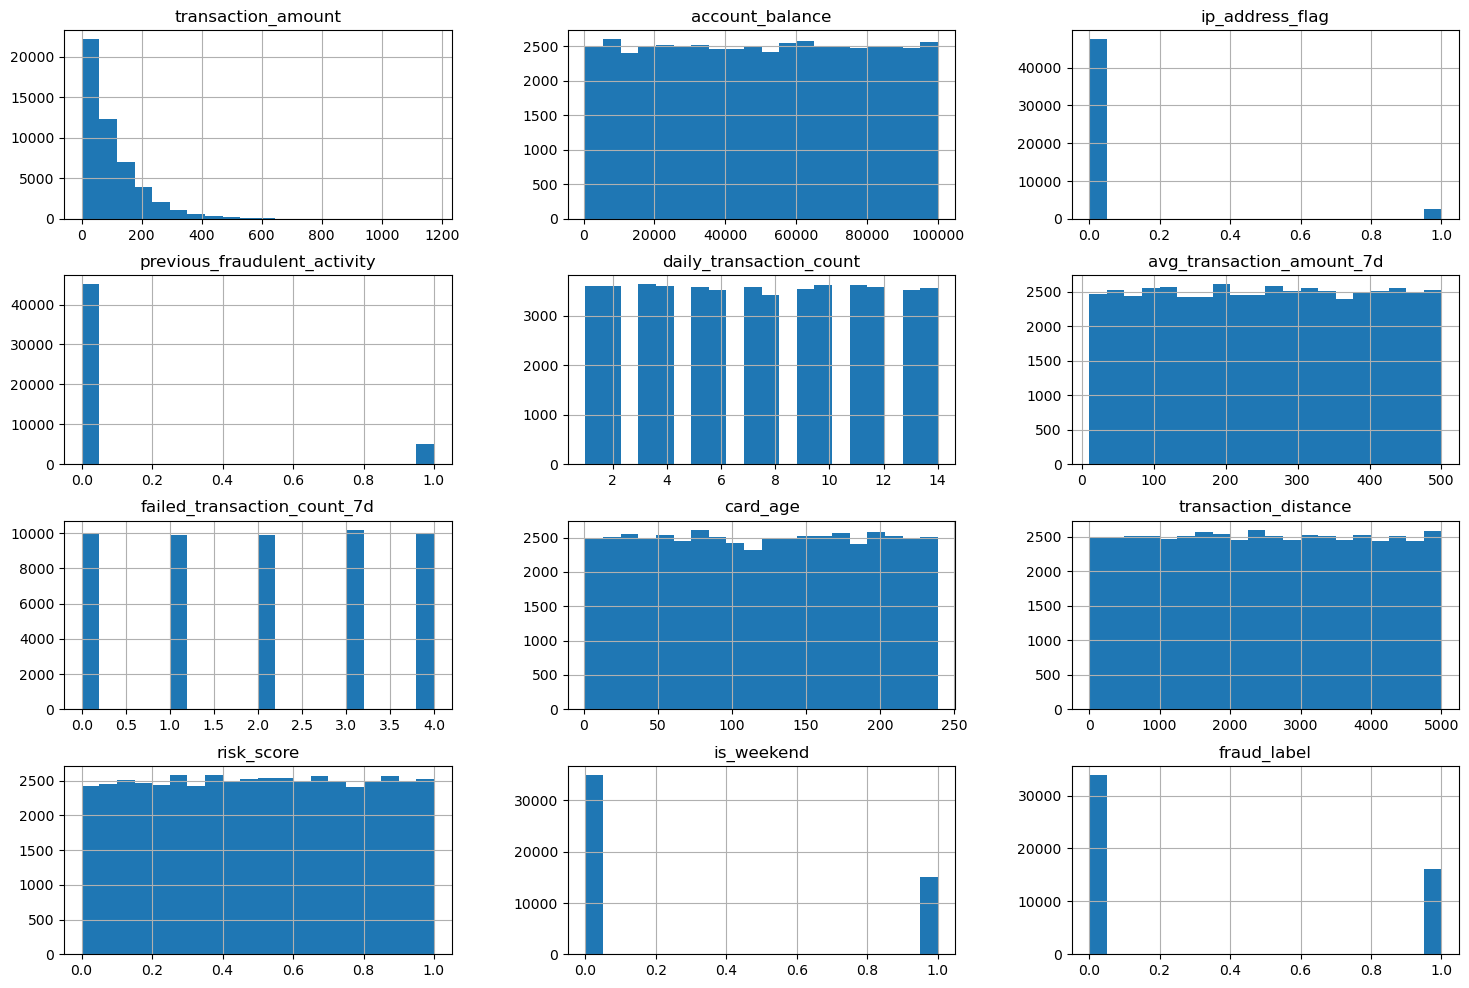

In [13]:
numeric_df.hist(figsize=(18, 12), bins=20)
plt.show()

### Spostrzeżenia
Widać, że zmienne daily_transaction_count i failed_transaction_count_7d przyjmują wartości z niewielkich zbiorów, jednak nie są to zmienne kategoryczne.

Zmienne ip_address_flag, is_weekend i fraud_label zgodnie z opisem danych są binarne.

Okazuje się, że zmienna previous_fraudulent_activity również.

Dominują rozkłady zbliżone do jednostajnych.

In [14]:
numeric_df['daily_transaction_count'].value_counts().sort_index()

daily_transaction_count
1     3598
2     3605
3     3634
4     3606
5     3582
6     3521
7     3574
8     3418
9     3538
10    3623
11    3620
12    3586
13    3524
14    3571
Name: count, dtype: int64

In [15]:
numeric_df['failed_transaction_count_7d'].value_counts().sort_index()

failed_transaction_count_7d
0    10014
1     9919
2     9897
3    10216
4     9954
Name: count, dtype: int64

### Boxplots

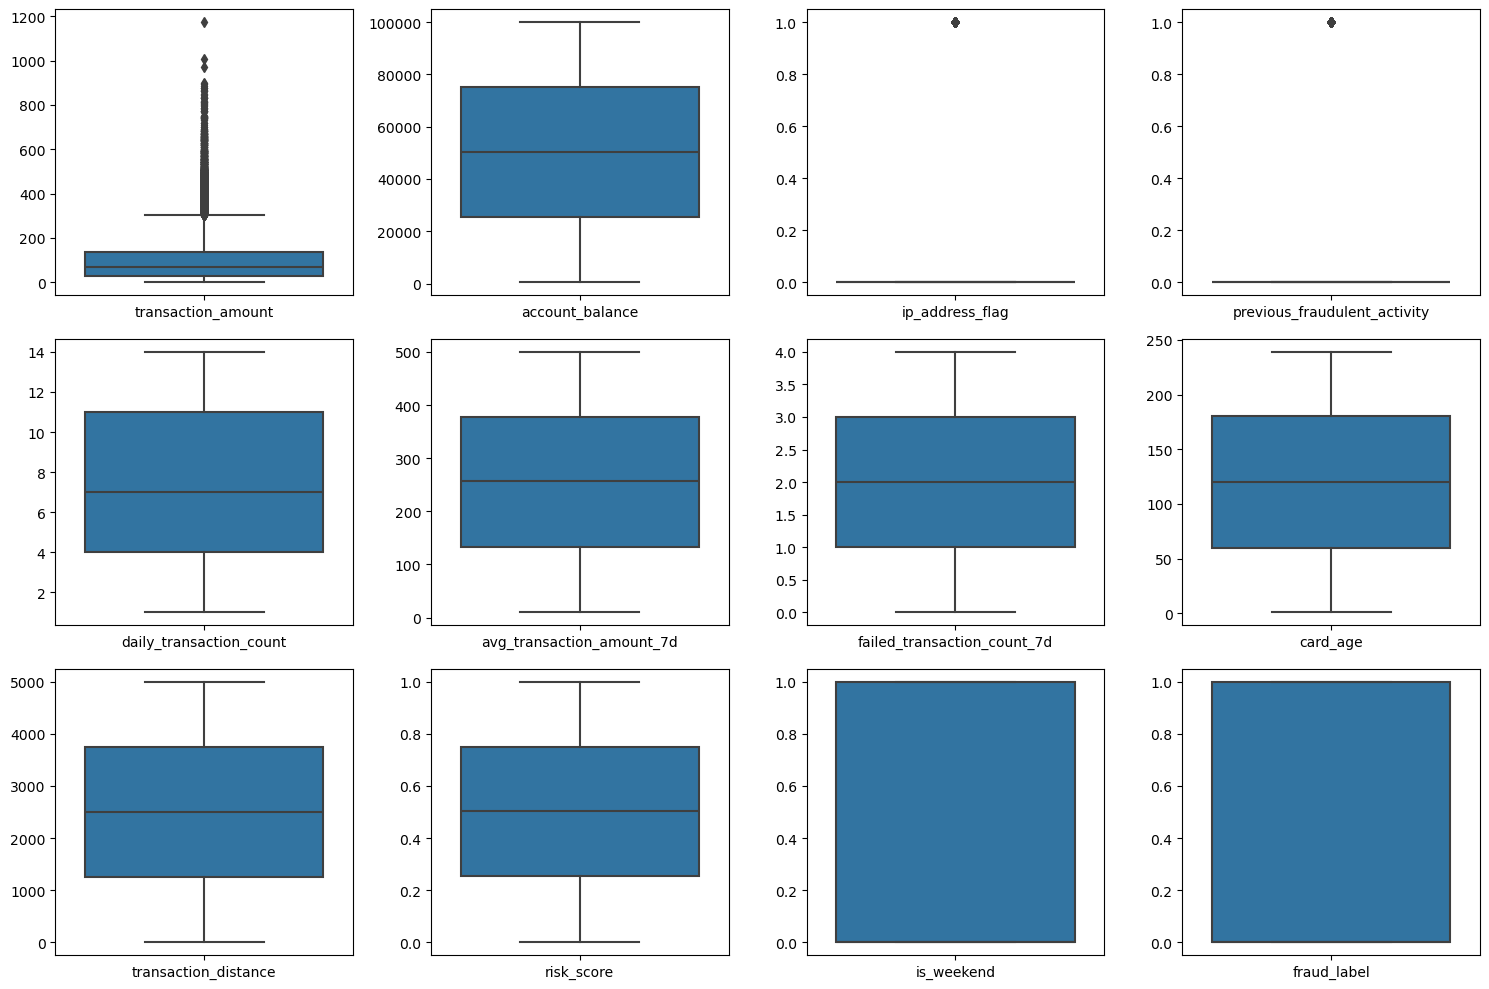

In [16]:
plt.figure(figsize=(15, 10))

for i, feature in enumerate(numeric_df, 1):
    plt.subplot(3, 4, i)
    sns.boxplot(data=df1[feature])
    plt.xticks([0], [feature])

plt.tight_layout()
plt.show()

### Outliers
Widzimy, że transaction_amount zawiera wiele outlierów, czego spodziewaliśmy się już patrząc na histogram, gdyż przeważają transakcje poniżej 200$. 

Jednak transakcje na wysokie sumy pieniężne mogą być potencjalnie ważne w kontekście oszustw finansowych.

In [17]:
numeric_df1 = numeric_df.drop(['ip_address_flag', 'previous_fraudulent_activity', 'is_weekend', 'fraud_label'],axis='columns')

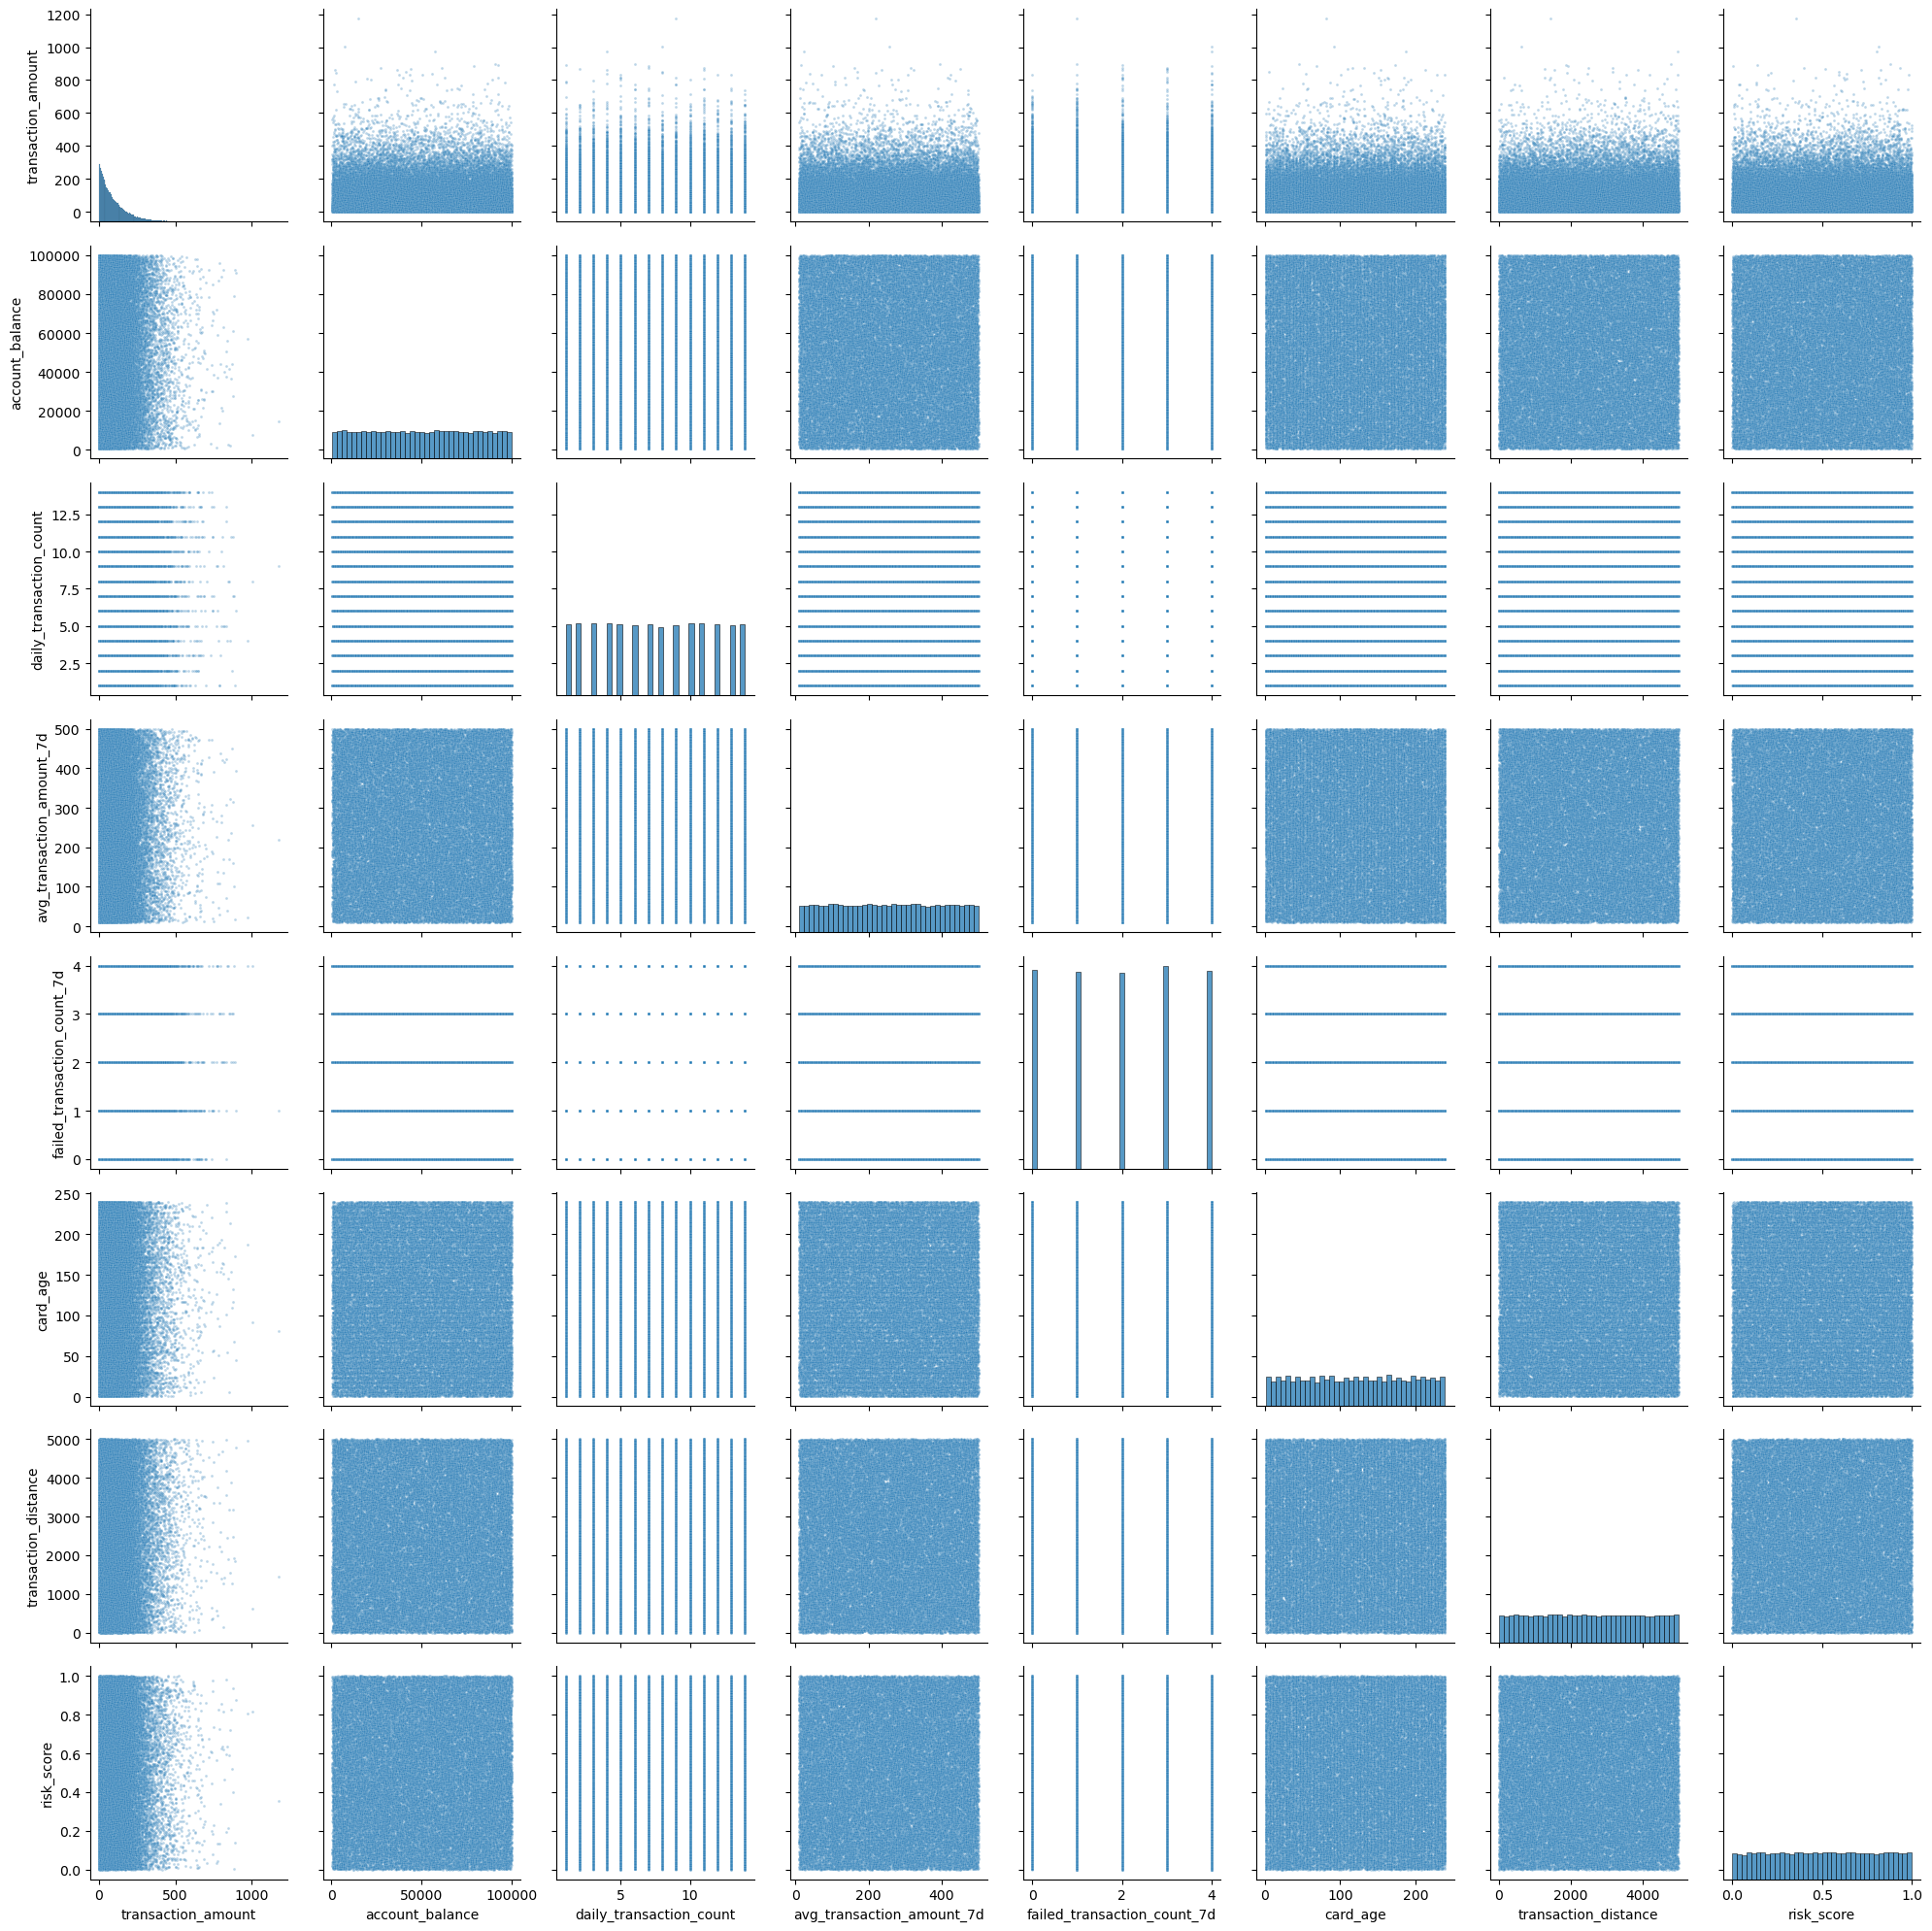

In [18]:
sns.pairplot(numeric_df1.iloc[:,:], plot_kws={'s': 4, 'alpha': 0.3})
plt.tight_layout()

### Zależności zmiennych numerycznych od binarnych

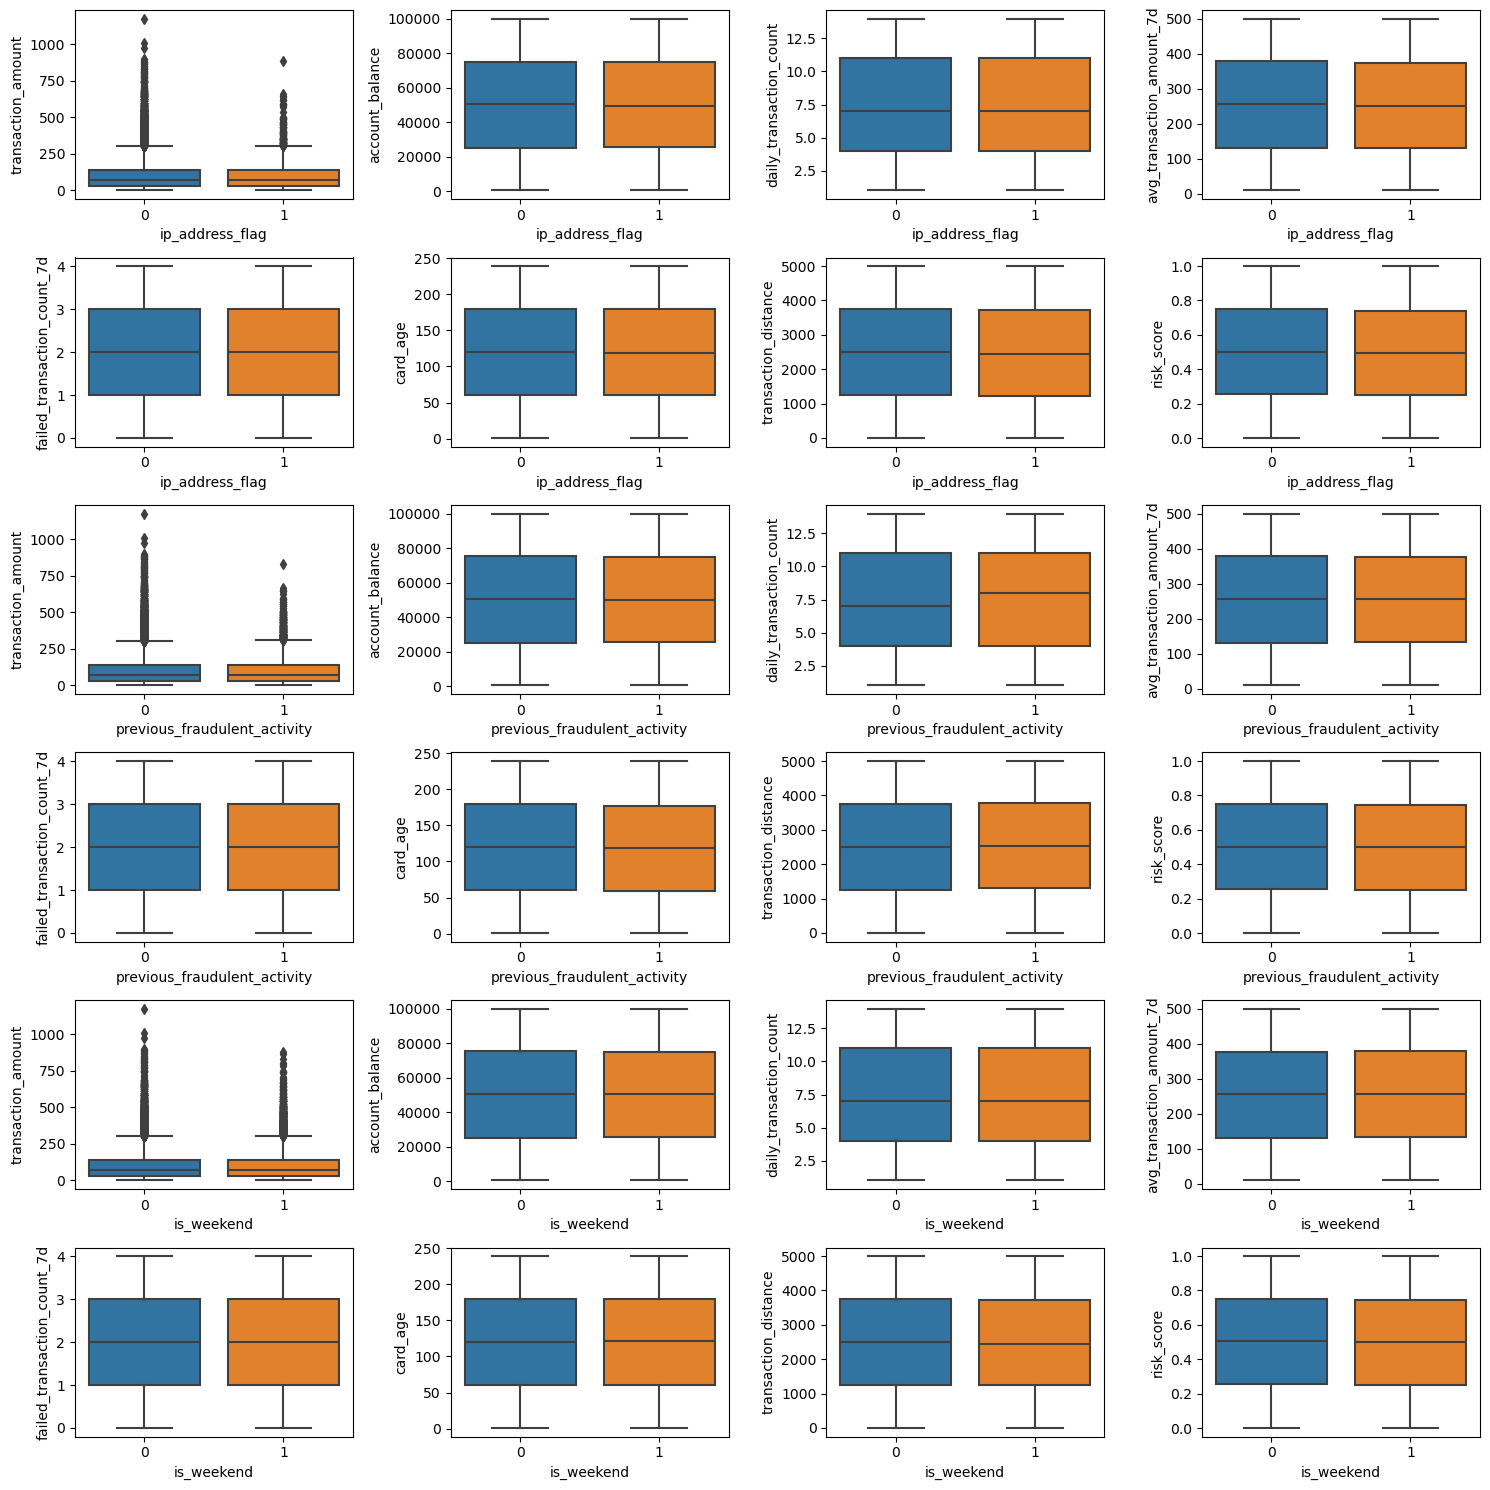

In [19]:
plt.figure(figsize=(15, 15))

for i, feature in enumerate(numeric_df1, 1):
    plt.subplot(6, 4, i)
    sns.boxplot(x='ip_address_flag', y=feature, data=numeric_df)

for i, feature in enumerate(numeric_df1, 1):
    plt.subplot(6, 4, i+8)
    sns.boxplot(x='previous_fraudulent_activity', y=feature, data=numeric_df)

for i, feature in enumerate(numeric_df1, 1):
    plt.subplot(6, 4, i+16)
    sns.boxplot(x='is_weekend', y=feature, data=numeric_df)
    
plt.tight_layout()
plt.show()

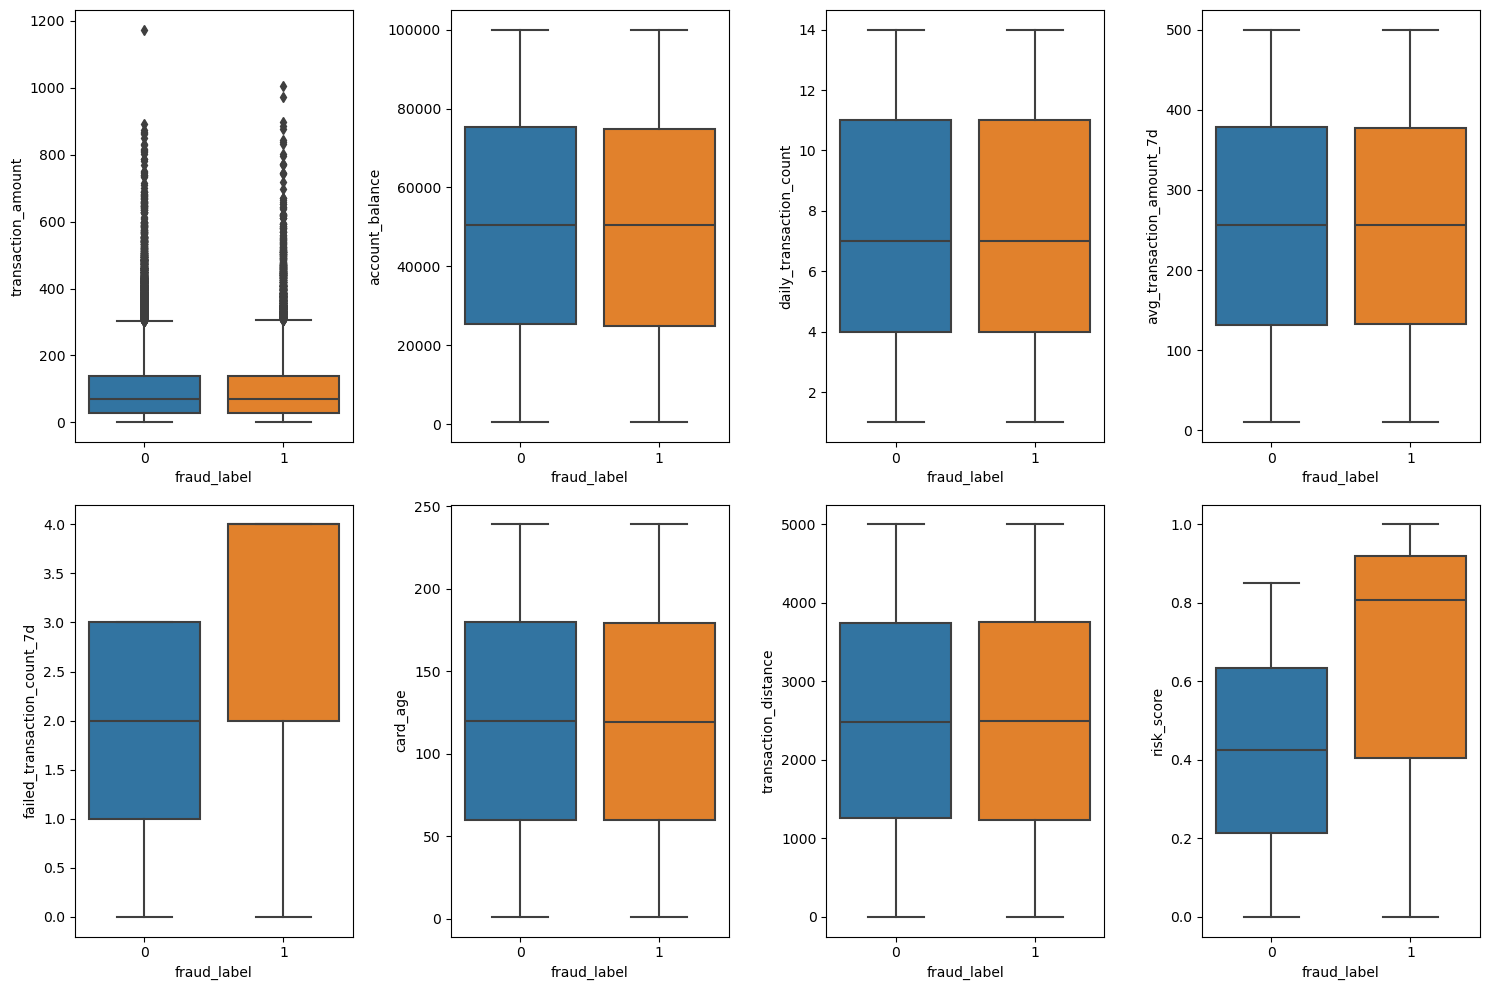

In [20]:
plt.figure(figsize=(15, 10))

for i, feature in enumerate(numeric_df1, 1):
    plt.subplot(2, 4, i)
    sns.boxplot(x='fraud_label', y=feature, data=numeric_df)

plt.tight_layout()
plt.show()

## Correlation heatmap for numerical features

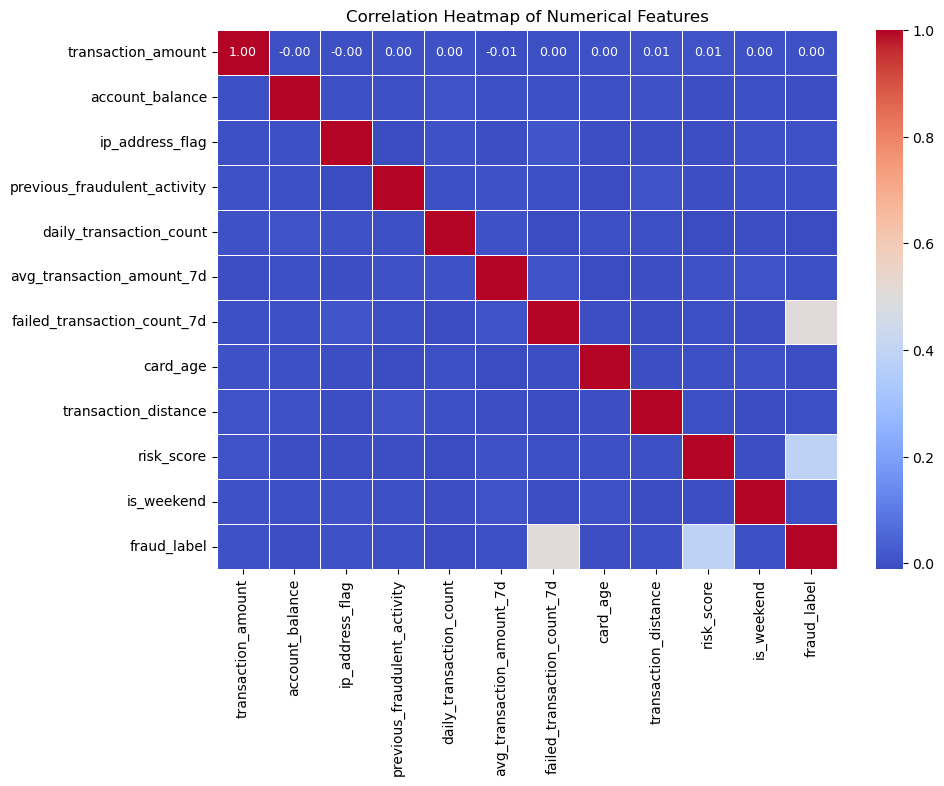

In [21]:
corr_matrix = numeric_df.corr()
plt.figure(figsize=(10, 7))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.4, annot_kws={"size": 9})
plt.title("Correlation Heatmap of Numerical Features")
plt.show()

### Spostrzeżenia
Dzięki boxplotom i heatmapie zauważamy korelację naszej zmiennej objaśnianej ze zmiennymi failed_transaction_count_7d i risk_score.

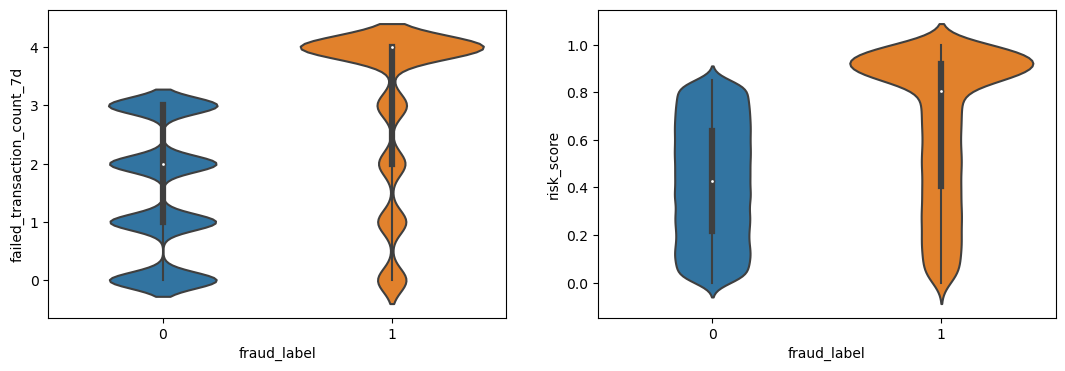

In [22]:
plt.figure(figsize=(13, 4))

plt.subplot(1, 2, 1)
sns.violinplot(x=df["fraud_label"], y=df["failed_transaction_count_7d"])

plt.subplot(1, 2, 2)
sns.violinplot(x=df["fraud_label"], y=df["risk_score"])

plt.show()

## Categorical variables

In [23]:
categorical_df1 = categorical_df.drop('timestamp',axis=1)
for col in categorical_df1:
    print(col, ":", categorical_df1[col].unique())

transaction_type : ['POS' 'Bank Transfer' 'Online' 'ATM Withdrawal']
device_type : ['Laptop' 'Mobile' 'Tablet']
location : ['Sydney' 'New York' 'Mumbai' 'Tokyo' 'London']
merchant_category : ['Travel' 'Clothing' 'Restaurants' 'Electronics' 'Groceries']
card_type : ['Amex' 'Mastercard' 'Visa' 'Discover']
authentication_method : ['Biometric' 'Password' 'OTP' 'PIN']


### Heatmaps based on contingency matrixes

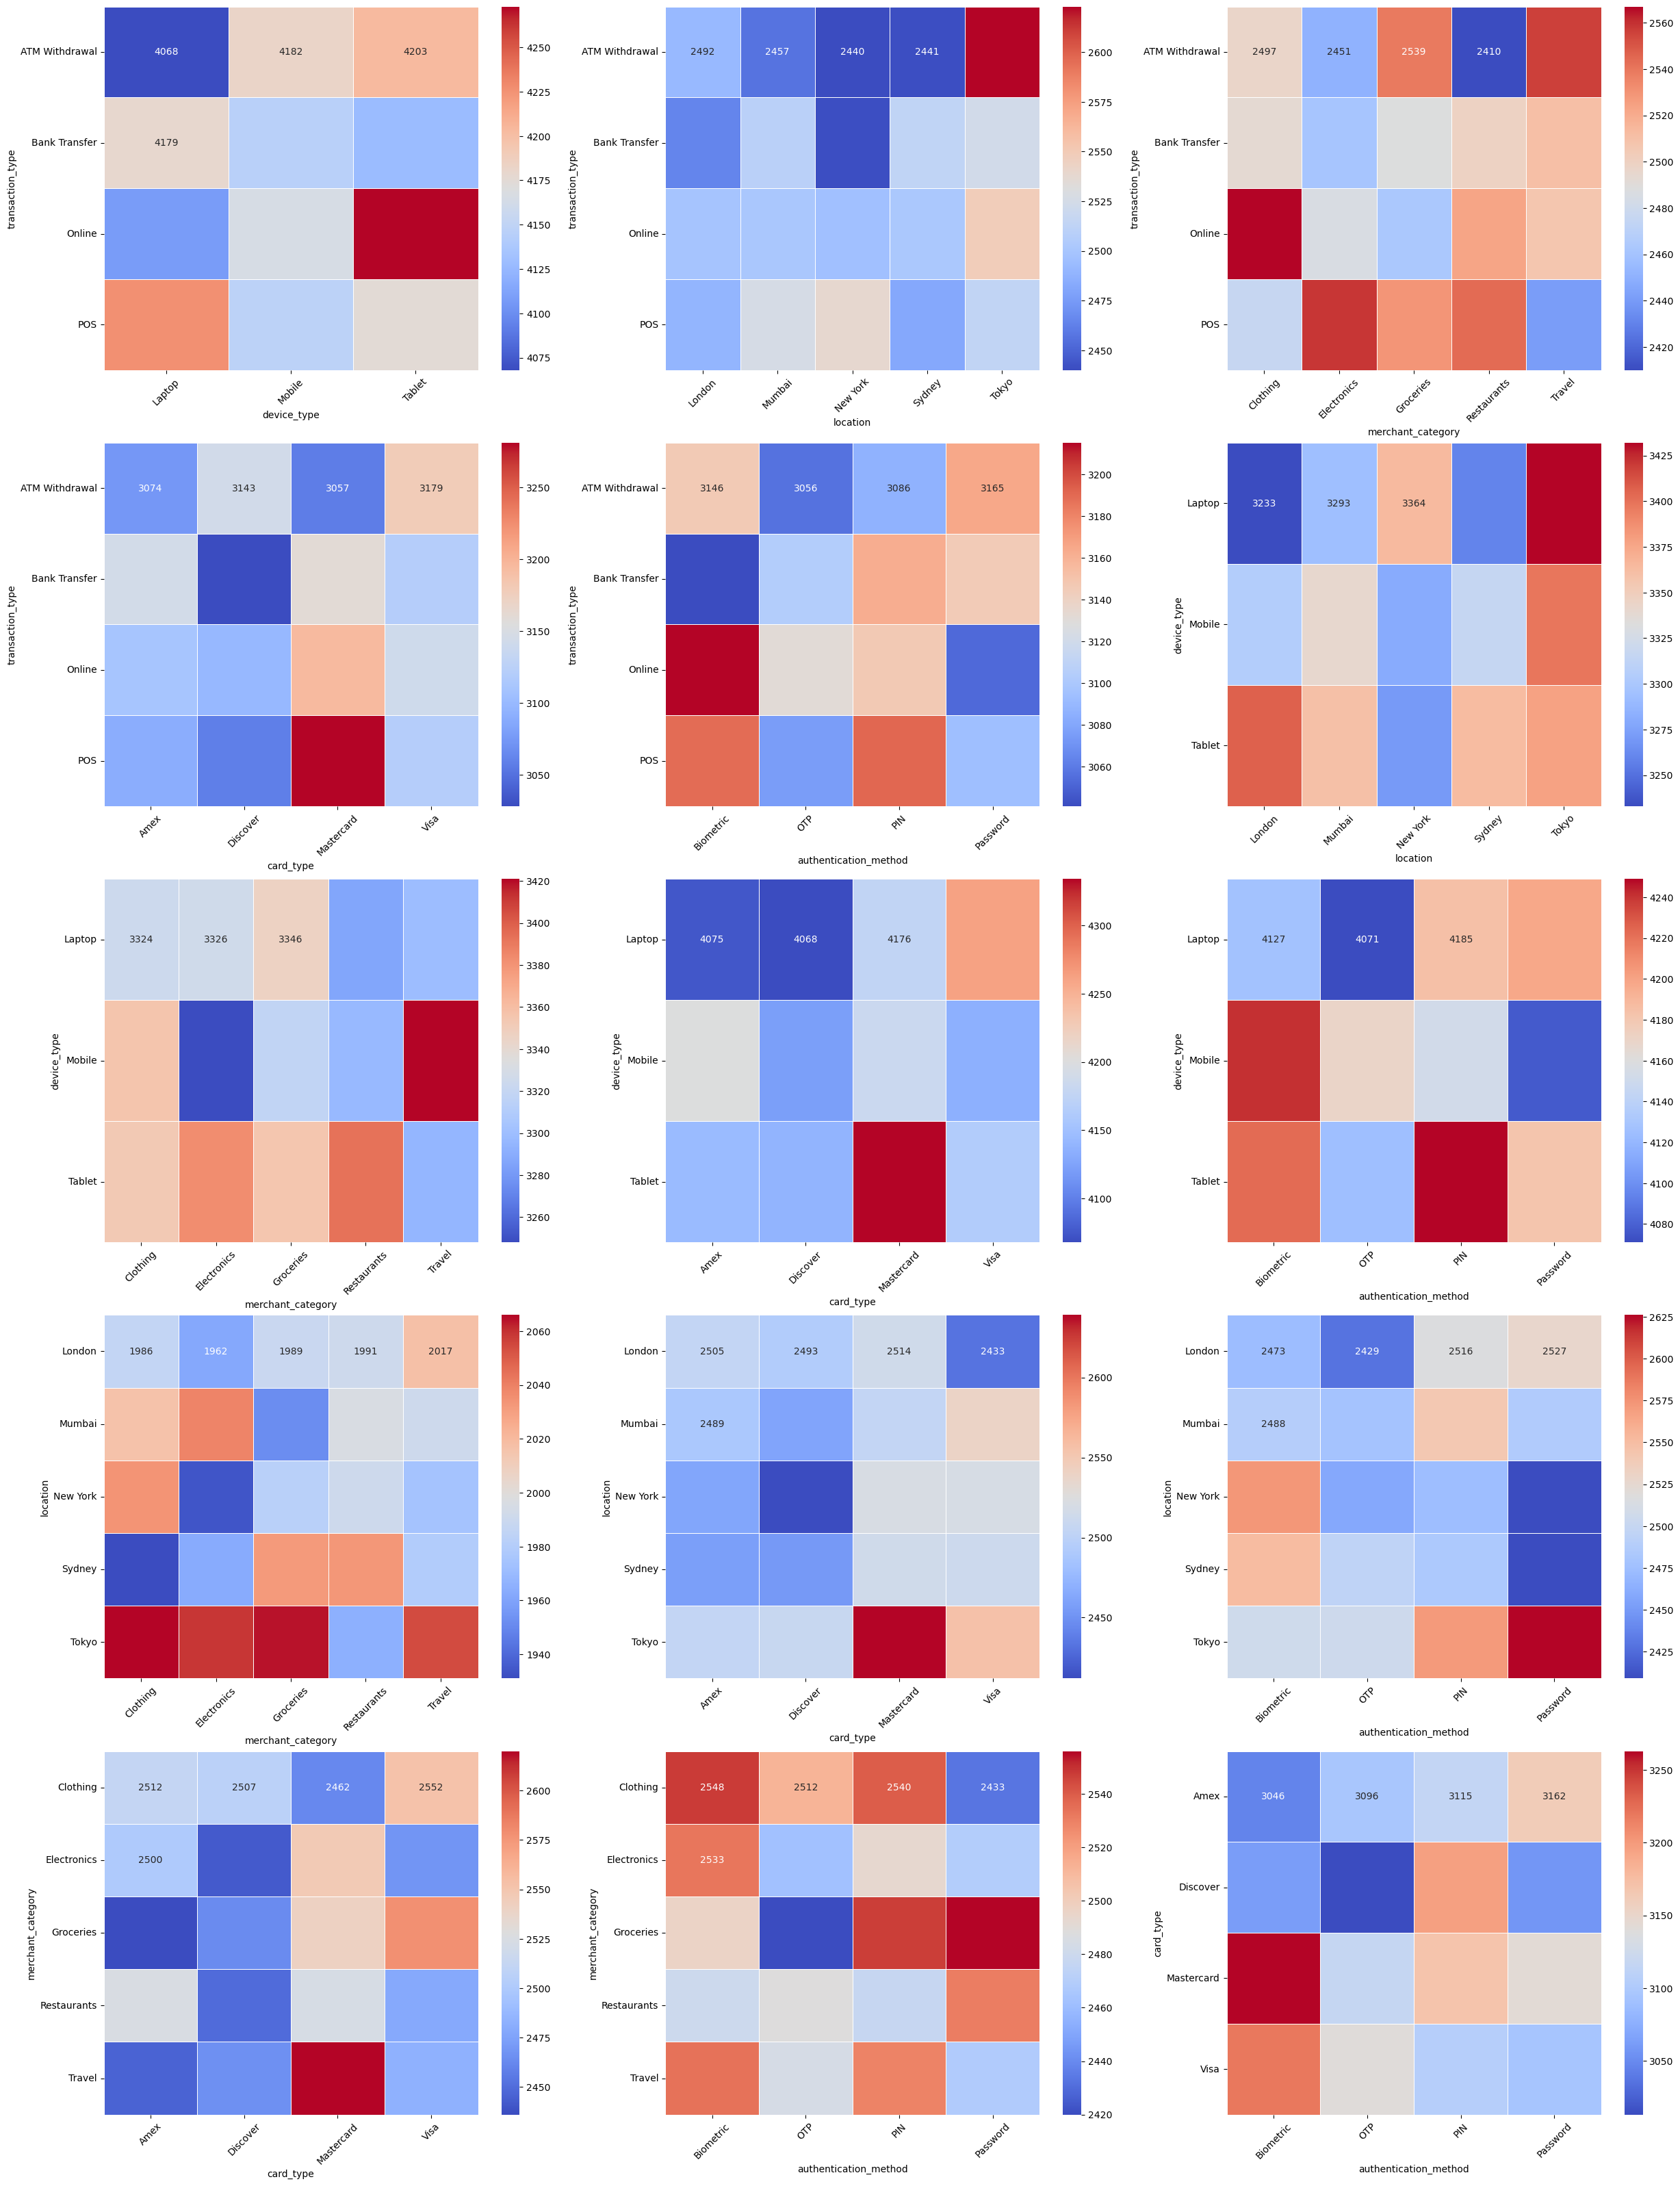

In [24]:
categorical_columns = ['transaction_type', 'device_type', 'location', 
                       'merchant_category', 'card_type', 'authentication_method']

k = 1
plt.figure(figsize=(30,40))
for i in range(len(categorical_columns)):
    for j in range(i + 1, len(categorical_columns)):
        col1 = categorical_columns[i]
        col2 = categorical_columns[j]
        
        contingency_table = pd.crosstab(categorical_df1[col1], categorical_df1[col2])

        plt.subplot(5, 3, k)
        k += 1
        sns.heatmap(contingency_table, cmap="coolwarm", annot=True, fmt="d", linewidths=0.5)
        plt.xlabel(col2)
        plt.ylabel(col1)
        plt.xticks(rotation=45)
        plt.yticks(rotation=0)

plt.tight_layout
plt.show()

### Barplots 

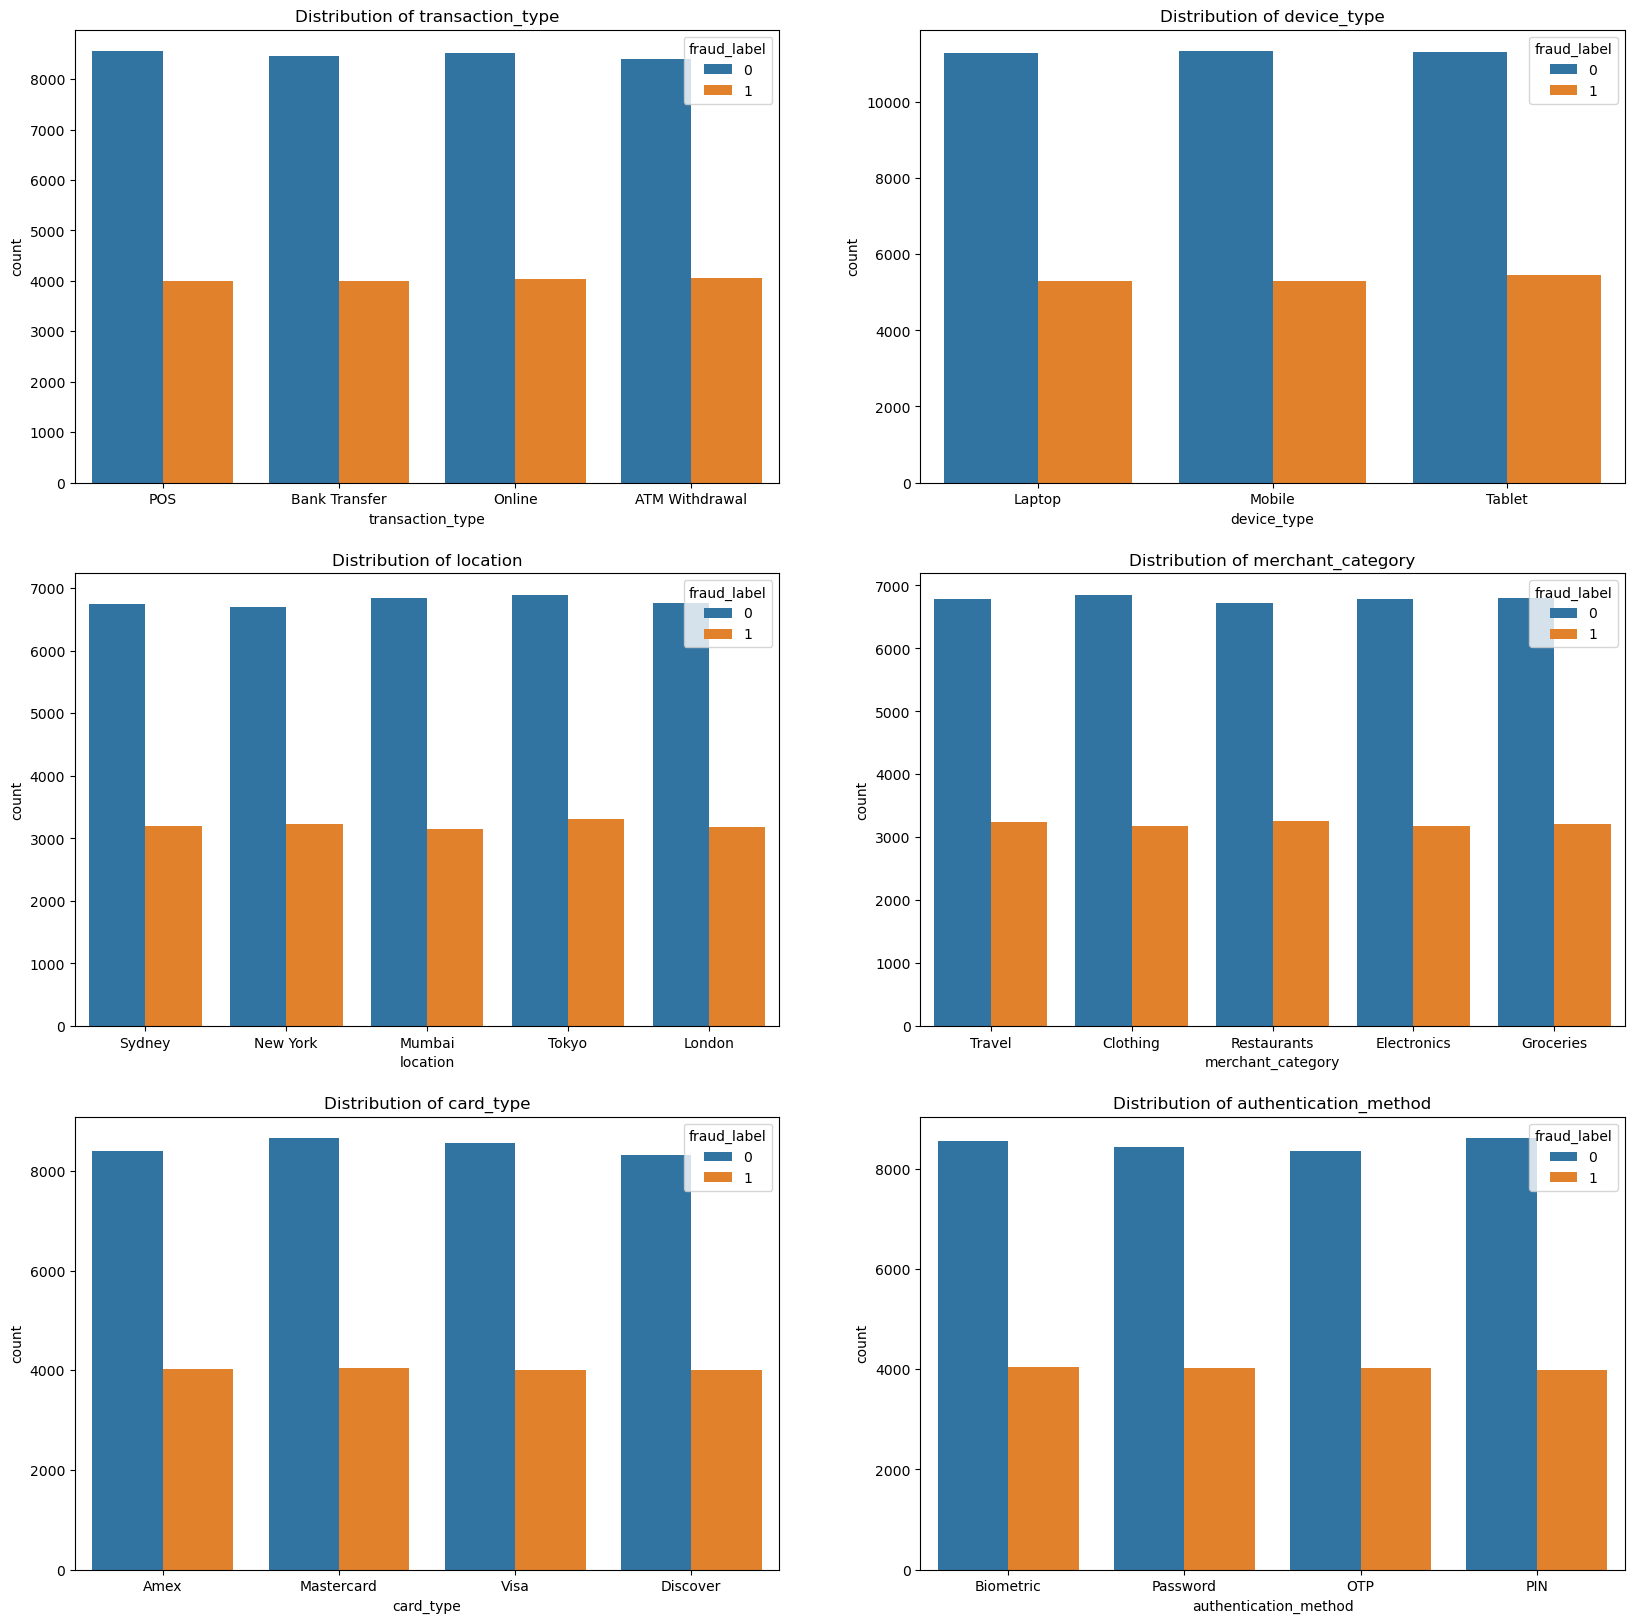

In [25]:
plt.figure(figsize=(20,20))
i=1
for col in categorical_df1:
    plt.subplot(3,2,i)
    i+=1
    plt.title(f"Distribution of {col}")
    sns.countplot(x=col, data=df, hue=df['fraud_label'].astype(str))
plt.show()

## Timestamp variable

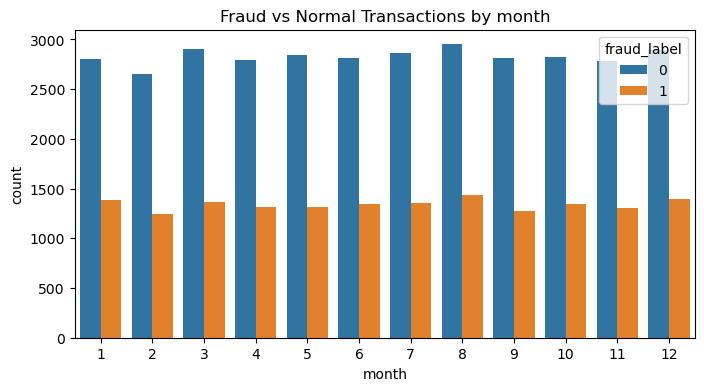

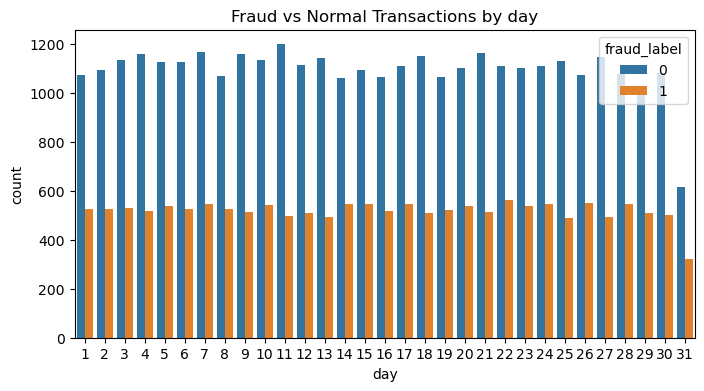

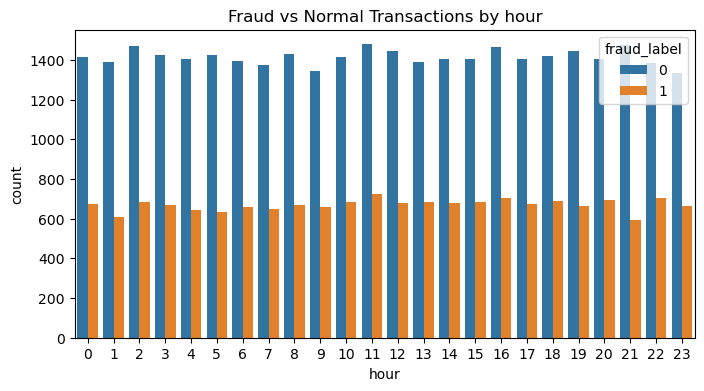

In [26]:
df1['month']=df1['timestamp'].dt.month
df1['day']=df1['timestamp'].dt.day
df1['hour']=df1['timestamp'].dt.hour

for col in ['month','day','hour']:
    plt.figure(figsize=(8,4))
    plt.title(f"Fraud vs Normal Transactions by {col}")
    sns.countplot(x=col, data=df1, hue=df1['fraud_label'].astype(str))
    plt.show()

# Wstęp do Uczenia Maszynowego - Projekt I
## Etap: Drugi Kamień Milowy 
### Autorzy: Krzysztof Osiński, Jakub Miszczak

## Import packages

In [20]:
import pandas as pd
import numpy as np
import sklearn 
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib
import warnings
warnings.filterwarnings('ignore')
np.random.seed(23)
import zipfile

# Fraud Detection Transactions Dataset - Feature Extraction

In [21]:
zip_path = "fraud-detection-transactions-dataset.zip"

with zipfile.ZipFile(zip_path, 'r') as z:
    with z.open("synthetic_fraud_dataset.csv") as file:
        df = pd.read_csv(file)

In [22]:
df.columns = df.columns.str.replace(" ","_").str.lower()
df1 = df.drop(['transaction_id','user_id'],axis='columns')
df1['timestamp'] = pd.to_datetime(df1['timestamp'])

In [23]:
X = df1.drop('fraud_label', axis='columns')
Y = df1['fraud_label']

from sklearn.preprocessing import MinMaxScaler

scaled_columns = X.select_dtypes(['int64', 'float64']).columns

scaler = MinMaxScaler()

X[scaled_columns] = scaler.fit_transform(X[scaled_columns])
X.describe()

,transaction_amount,timestamp,account_balance,ip_address_flag,previous_fraudulent_activity,daily_transaction_count,avg_transaction_amount_7d,failed_transaction_count_7d,card_age,transaction_distance,risk_score,is_weekend
count,50000.0000,50000,50000.0000,50000.0000,50000.0000,50000.0000,50000.0000,50000.0000,50000.0000,50000.0000,50000.0000,50000.0000
mean,0.0847,2023-07-02 12:47:11.063999744,0.5004,0.0502,0.0984,0.4989,0.5006,0.5009,0.5000,0.4998,0.5015,0.2996
min,0.0000,2023-01-01 00:01:00,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
25%,0.0244,2023-04-02 03:35:30,0.2498,0.0000,0.0000,0.2308,0.2492,0.2500,0.2479,0.2513,0.2539,0.0000
50%,0.0593,2023-07-02 14:00:00,0.5014,0.0000,0.0000,0.4615,0.5022,0.5000,0.5000,0.4981,0.5022,0.0000
75%,0.1183,2023-10-01 07:13:00,0.7499,0.0000,0.0000,0.7692,0.7511,0.7500,0.7521,0.7493,0.7495,1.0000
max,1.0000,2023-12-31 23:50:00,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
std,0.0841,NaN,0.2891,0.2184,0.2979,0.3107,0.2885,0.3536,0.2899,0.2884,0.2878,0.4581


## Variance Inflation Factor (VIF)
Wartość VIF w okolicach 1 mówi o bardzo małej współliniowości cech.

In [24]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

def calculate_vif(df):
    vif_df = pd.DataFrame()
    vif_df['Column'] = df.columns
    vif_df['VIF'] = [variance_inflation_factor(df.values,i) for i in range(df.shape[1])]
    return vif_df

In [25]:
calculate_vif(X[scaled_columns])

,Column,VIF
0,transaction_amount,1.9272
1,account_balance,3.4615
2,ip_address_flag,1.0504
3,previous_fraudulent_activity,1.1036
4,daily_transaction_count,3.1596
5,avg_transaction_amount_7d,3.4722
6,failed_transaction_count_7d,2.7309
7,card_age,3.4294
8,transaction_distance,3.4529
9,risk_score,3.4787


Widzimy, że nasze cechy bazowe nie wykazują korelacji.

## Weight of Evidence (WOE)

In [26]:
# Funkcja do policzenia WOE i IV dla naszych cech
def calculate_woe_iv(df, feature, target):
    
    grouped = df.groupby(feature)[target].agg(['count','sum'])
    grouped = grouped.rename(columns={'count': 'total', 'sum': 'good'})
    grouped['bad']=grouped['total']-grouped['good']
    
    total_good = grouped['good'].sum()
    total_bad = grouped['bad'].sum()
    
    grouped['good_score'] = grouped['good'] / total_good
    grouped['bad_score'] = grouped['bad'] / total_bad
    grouped['woe'] = np.log(grouped['good_score']/ grouped['bad_score'])
    grouped['iv'] = (grouped['good_score'] -grouped['bad_score'])*grouped['woe']
    
    grouped['woe'] = grouped['woe'].replace([np.inf, -np.inf], 0)
    grouped['iv'] = grouped['iv'].replace([np.inf, -np.inf], 0)
    
    total_iv = grouped['iv'].sum()
    
    return grouped, total_iv

In [27]:
iv_values = {}

discrete_columns = ['ip_address_flag', 'previous_fraudulent_activity', 'daily_transaction_count', 
                                                   'failed_transaction_count_7d', 'is_weekend', 'hour', 'weekday', 'is_night',
                                                  'is_large_transaction', 'transaction_bin', 'high_failed_tx_flag', 
                                                   'high_transaction_distance', 'high_sqrt_risk_score', 'low_balance_flag']
# Liczymy IV 
for feature in X.columns:
    # Jeśli kolumna kategoryczna lub dyskretna to względem kategorii
    if X[feature].dtype == 'object' or feature in discrete_columns:
        _, iv = calculate_woe_iv(pd.concat([X, Y],axis=1), feature, 'fraud_label' )
    # Jeśli kolumna numeryczna to dzielimy na biny i liczymy względem binów
    else:
        X_binned = pd.cut(X[feature], bins=10, labels=False)
        _, iv = calculate_woe_iv(pd.concat([X_binned, Y],axis=1), feature, 'fraud_label' )
    iv_values[feature] = iv
    
# Eleganckie zapisanie wyników 
pd.set_option('display.float_format', lambda x: '{:.4f}'.format(x))

iv_df = pd.DataFrame(list(iv_values.items()), columns=['Feature', 'IV'])
iv_df = iv_df.sort_values(by='IV', ascending=False)

## Information Value (IV)
IV < 0.02  --> brak wartości predykcyjnej

0.3 <= IV < 0.5  --> silna wartość predykcyjna

IV >= 0.5  --> bardzo silna wartość predykcyjna (trzeba uważać na overfitting)

In [28]:
iv_df

,Feature,IV
11,failed_transaction_count_7d,0.5995
16,risk_score,0.4483
9,daily_transaction_count,0.0009
3,account_balance,0.0009
14,transaction_distance,0.0009
13,card_age,0.0005
2,timestamp,0.0004
10,avg_transaction_amount_7d,0.0003
15,authentication_method,0.0003
5,location,0.0002


### Spostrzeżenia
Na tym etapie wartość predykcyjną wykazują jedynie cechy 'failed_transaction_count_7d' i 'risk_score'.

## New Features
Teraz poprzez interakcje między zmiennymi i transformacje zmiennych spróbujmy znaleźć więcej ciekawych cech.

In [29]:
# Tworzenie nowych cech
df1['failed_tx_risk_interaction'] = df1['failed_transaction_count_7d'] * df1['risk_score']
df1['amount_risk_interaction'] = df1['transaction_amount'] * df1['risk_score']
df1['balance_to_avg_tx_ratio'] = df1['account_balance'] / df1['avg_transaction_amount_7d']

# Detekcja wartości odstających - flagi
df1['low_balance_flag'] = (df1['account_balance'] < df1['transaction_amount']).astype(int)
df1['high_transaction_distance'] = (df1['transaction_distance'] > df1['transaction_distance'].quantile(0.95)).astype(int)
df1['high_failed_tx_flag'] = (df1['failed_transaction_count_7d'] > 3).astype(int)
df1["is_large_transaction"] = (df1["transaction_amount"] > df1["transaction_amount"].quantile(0.95)).astype(int)

# Transformacje matematyczne
df1['log_transaction_amount'] = np.log1p(df1['transaction_amount'])
df1["sqrt_transaction_amount"] = np.sqrt(df1["transaction_amount"])
df1['log_account_balance'] = np.log1p(df1['account_balance'])
df1['sqrt_risk_score'] = np.sqrt(df1['risk_score'])
df1['sqrt_transaction_distance'] = np.sqrt(df1['transaction_distance'])  

df1['high_sqrt_risk_score'] = (df1['sqrt_risk_score'] > 0.9).astype(int)

# Ekstrakcja cech czasowych
df1['hour'] = df1['timestamp'].dt.hour
df1['weekday'] = df1['timestamp'].dt.dayofweek
df1['is_night'] = ((df1['hour'] >= 0) & (df1['hour'] <= 6)).astype(int)

# One-hot encoding dla cech kategorycznych
categorical_features = ['authentication_method', 'device_type', 'card_type', 'transaction_type', 'merchant_category', 'location']
df1 = pd.get_dummies(df1, columns=categorical_features, drop_first=True)

## Histograms for some new features

In [30]:
features = ['sqrt_risk_score', 'failed_tx_risk_interaction',
            'failed_transaction_count_7d', 'risk_score']

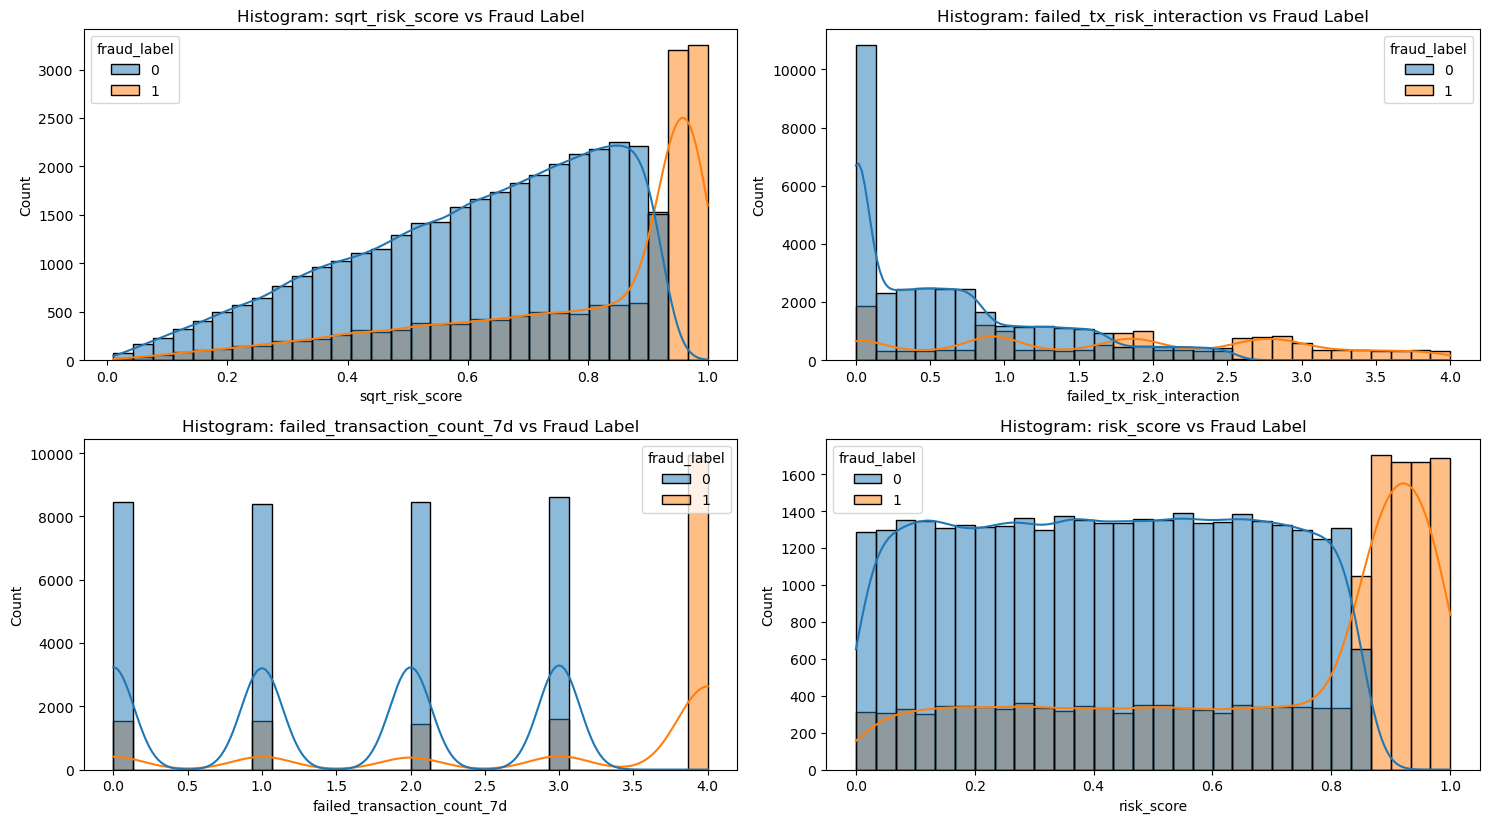

In [31]:
plt.figure(figsize=(15, 12))

for i, feature in enumerate(features, 1):
    plt.subplot(3, 2, i)
    sns.histplot(data=df1, x=feature, hue='fraud_label', kde=True, bins=30, alpha=0.5)
    plt.title(f'Histogram: {feature} vs Fraud Label')

plt.tight_layout()
plt.show()

### Scaling

In [32]:
X2 = df1.drop('fraud_label', axis='columns')
scaled_columns = X2.select_dtypes(['int64', 'float64']).columns

scaler = MinMaxScaler()

X2[scaled_columns] = scaler.fit_transform(X2[scaled_columns])

In [44]:
X2.describe().T

,count,mean,min,25%,50%,75%,max,std
transaction_amount,50000.0000,0.0847,0.0000,0.0244,0.0593,0.1183,1.0000,0.0841
timestamp,50000,2023-07-02 12:47:11.063999744,2023-01-01 00:01:00,2023-04-02 03:35:30,2023-07-02 14:00:00,2023-10-01 07:13:00,2023-12-31 23:50:00,NaN
account_balance,50000.0000,0.5004,0.0000,0.2498,0.5014,0.7499,1.0000,0.2891
ip_address_flag,50000.0000,0.0502,0.0000,0.0000,0.0000,0.0000,1.0000,0.2184
previous_fraudulent_activity,50000.0000,0.0984,0.0000,0.0000,0.0000,0.0000,1.0000,0.2979
daily_transaction_count,50000.0000,0.4989,0.0000,0.2308,0.4615,0.7692,1.0000,0.3107
avg_transaction_amount_7d,50000.0000,0.5006,0.0000,0.2492,0.5022,0.7511,1.0000,0.2885
failed_transaction_count_7d,50000.0000,0.5009,0.0000,0.2500,0.5000,0.7500,1.0000,0.3536
card_age,50000.0000,0.5000,0.0000,0.2479,0.5000,0.7521,1.0000,0.2899
transaction_distance,50000.0000,0.4998,0.0000,0.2513,0.4981,0.7493,1.0000,0.2884


## IV of New Features

In [34]:
iv_values2 = {}
for feature in X2.columns:
    # Jeśli kolumna kategoryczna lub dyskretna to względem kategorii
    if X2[feature].dtype == 'object' or feature in discrete_columns:
        _, iv = calculate_woe_iv(pd.concat([X2, Y],axis=1), feature, 'fraud_label' )
    # Jeśli kolumna numeryczna to dzielimy na biny i liczymy względem binów
    else:
        X2_binned = pd.cut(X2[feature], bins=10, labels=False)
        _, iv = calculate_woe_iv(pd.concat([X2_binned, Y],axis=1), feature, 'fraud_label' )
    iv_values2[feature] = iv
    
# Eleganckie zapisanie wyników 
pd.set_option('display.float_format', lambda x: '{:.4f}'.format(x))

iv_df2 = pd.DataFrame(list(iv_values2.items()), columns=['Feature', 'IV'])
iv_df2 = iv_df2.sort_values(by='IV', ascending=False)
iv_df2

,Feature,IV
22,sqrt_risk_score,1.3834
24,high_sqrt_risk_score,1.3605
12,failed_tx_risk_interaction,0.8859
7,failed_transaction_count_7d,0.5995
17,high_failed_tx_flag,0.5987
10,risk_score,0.4483
13,amount_risk_interaction,0.1035
25,hour,0.0023
23,sqrt_transaction_distance,0.0010
5,daily_transaction_count,0.0009


## Correlations with target feature (fraud_label)

In [35]:
X_numeric = X2.select_dtypes(include=['number'])
correlations = X_numeric.corrwith(Y).sort_values(ascending=False)
print(correlations)

high_failed_tx_flag             0.7245
high_sqrt_risk_score            0.5358
failed_tx_risk_interaction      0.5297
failed_transaction_count_7d     0.5099
risk_score                      0.3858
sqrt_risk_score                 0.3290
amount_risk_interaction         0.1702
high_transaction_distance       0.0060
hour                            0.0058
weekday                         0.0053
ip_address_flag                 0.0030
transaction_amount              0.0019
sqrt_transaction_amount         0.0012
avg_transaction_amount_7d       0.0007
log_transaction_amount          0.0001
is_weekend                      0.0001
transaction_distance           -0.0001
is_large_transaction           -0.0005
previous_fraudulent_activity   -0.0007
sqrt_transaction_distance      -0.0013
low_balance_flag               -0.0031
card_age                       -0.0031
account_balance                -0.0032
balance_to_avg_tx_ratio        -0.0034
log_account_balance            -0.0035
daily_transaction_count  

## SelectKBest
Szukamy najlepszych cech.

In [47]:
from sklearn.feature_selection import SelectKBest, f_classif

selector = SelectKBest(score_func=f_classif, k=6)
X_selected = selector.fit_transform(X_numeric, Y)

feature_scores = pd.DataFrame({"Feature": X_numeric.columns, "Score": selector.scores_})
feature_scores = feature_scores.sort_values(by="Score", ascending=False)

print(feature_scores)

                         Feature      Score
16           high_failed_tx_flag 55252.0156
23          high_sqrt_risk_score 20132.2061
11    failed_tx_risk_interaction 19501.9641
6    failed_transaction_count_7d 17564.0057
9                     risk_score  8743.6565
21               sqrt_risk_score  6068.5502
12       amount_risk_interaction  1490.8018
26                      is_night     3.3616
4        daily_transaction_count     2.4954
15     high_transaction_distance     1.8138
24                          hour     1.6948
25                       weekday     1.3895
20           log_account_balance     0.6263
13       balance_to_avg_tx_ratio     0.5649
1                account_balance     0.4972
7                       card_age     0.4868
14              low_balance_flag     0.4735
2                ip_address_flag     0.4583
0             transaction_amount     0.1807
22     sqrt_transaction_distance     0.0807
19       sqrt_transaction_amount     0.0726
3   previous_fraudulent_activity

## Random Forest Clasifier: Feature Importances
Szukamy informacji, jak bardzo dana cecha wpływa na podjęcie decyzji w modelu.

In [42]:
from sklearn.ensemble import RandomForestClassifier

selected_features = iv_df2[iv_df2['IV'] >= 0.001]['Feature'].tolist()
X_final = X2[selected_features]
X_final.drop('high_failed_tx_flag', axis='columns')

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_numeric, Y)

feature_importances = pd.Series(model.feature_importances_, index=X_numeric.columns).sort_values(ascending=False)
print(feature_importances)

print(feature_importances.sum())

failed_transaction_count_7d    0.2668
high_failed_tx_flag            0.2661
sqrt_risk_score                0.1757
risk_score                     0.1363
high_sqrt_risk_score           0.0910
failed_tx_risk_interaction     0.0567
amount_risk_interaction        0.0041
transaction_amount             0.0010
sqrt_transaction_amount        0.0007
log_transaction_amount         0.0007
sqrt_transaction_distance      0.0001
transaction_distance           0.0001
avg_transaction_amount_7d      0.0001
balance_to_avg_tx_ratio        0.0001
log_account_balance            0.0001
account_balance                0.0001
card_age                       0.0001
hour                           0.0001
daily_transaction_count        0.0001
weekday                        0.0000
is_large_transaction           0.0000
is_weekend                     0.0000
ip_address_flag                0.0000
high_transaction_distance      0.0000
previous_fraudulent_activity   0.0000
is_night                       0.0000
low_balance_

## Lasso: Select From Model

In [37]:
from sklearn.linear_model import Lasso
from sklearn.feature_selection import SelectFromModel

X2_lasso = X2.astype({col: int for col in X2.select_dtypes(include=['bool']).columns})
X2_lasso = X2_lasso.select_dtypes(exclude=['object', 'datetime'])
X2_lasso = X2_lasso.clip(lower=X2_lasso.quantile(0.01), upper=X2_lasso.quantile(0.99), axis=1)

# Tworzymy model Lasso (L1)
lasso = Lasso(alpha=0.01)  
lasso.fit(X2_lasso, Y)

# Wybór cechy na podstawie współczynników Lasso
selector = SelectFromModel(lasso, prefit=True)
selected_features = X2_lasso.columns[selector.get_support()]

# DataFrame z wynikami
feature_importance = pd.DataFrame({'Feature': X2_lasso.columns, 'Coefficient': lasso.coef_})
feature_importance['Selected'] = feature_importance['Feature'].isin(selected_features)

feature_importance = feature_importance.reindex(feature_importance['Coefficient'].abs().sort_values(ascending=False).index)

print(feature_importance)

                           Feature  Coefficient  Selected
16             high_failed_tx_flag       0.7860      True
23            high_sqrt_risk_score       0.5731      True
34                  card_type_Visa      -0.0000     False
26                        is_night      -0.0000     False
27       authentication_method_OTP      -0.0000     False
28       authentication_method_PIN      -0.0000     False
29  authentication_method_Password       0.0000     False
30              device_type_Mobile       0.0000     False
31              device_type_Tablet       0.0000     False
32              card_type_Discover       0.0000     False
33            card_type_Mastercard      -0.0000     False
35  transaction_type_Bank Transfer      -0.0000     False
24                            hour       0.0000     False
36         transaction_type_Online       0.0000     False
37            transaction_type_POS      -0.0000     False
38   merchant_category_Electronics       0.0000     False
39     merchan

# Wstęp do Uczenia Maszynowego - Projekt I
## Etap: Kamień Milowy III
### Autorzy: Krzysztof Osiński, Jakub Miszczak

## Import packages 

In [12]:
import pandas as pd
import numpy as np
import sklearn 
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib
import warnings
warnings.filterwarnings('ignore')
np.random.seed(23)
import zipfile

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split, cross_val_score, cross_val_predict, StratifiedKFold, GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, RocCurveDisplay, accuracy_score, f1_score,  precision_score, recall_score, precision_recall_curve

from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.linear_model import LogisticRegression


## Load data

In [2]:
zip_path = "fraud-detection-transactions-dataset.zip"

with zipfile.ZipFile(zip_path, 'r') as z:
    with z.open("synthetic_fraud_dataset.csv") as file:
        df = pd.read_csv(file)

df.columns = df.columns.str.replace(" ","_").str.lower()
df1 = df.drop(['transaction_id','user_id'],axis='columns')
df1['timestamp'] = pd.to_datetime(df1['timestamp'])

X = df1.drop('fraud_label', axis='columns')
Y = df1['fraud_label']

scaled_columns = X.select_dtypes(['int64', 'float64']).columns

scaler = MinMaxScaler()

X[scaled_columns] = scaler.fit_transform(X[scaled_columns])

## Przypomnienie wyników z kamienia milowego II:

Dzięki analizie i procesowi inżynierii cech w trakcie kamieni milowych I i II doszliśmy do wniosku, że większość cech nie ma potencjału predykcyjnego, lecz może wprowadzić niepotrzebny szum, więc skupiliśmy się na najważniejszych zmiennych.
Ostatecznie postanowiliśmy zachować następujące cechy: 
- failed_transaction_count_7d,
- risk_score, 
- failed_tx_risk_interaction,
- failed_tx_ratio
- amount_risk_interaction.

In [3]:
X['failed_tx_risk_interaction'] = X['failed_transaction_count_7d'] * X['risk_score']
X['failed_tx_ratio'] = X['failed_transaction_count_7d'] / (X['daily_transaction_count'] + 1)
X['amount_risk_interaction'] = X['transaction_amount'] * X['risk_score']

# Wybrane cechy
selected_features = [
    'failed_tx_ratio',
    'failed_tx_risk_interaction',
    'failed_transaction_count_7d',
    'risk_score',
    'amount_risk_interaction'
]

X_selected = X[selected_features]

In [4]:
print(f'Finalny kształt danych: {X_selected.shape}')
X_selected.head()

Finalny kształt danych: (50000, 5)


,failed_tx_ratio,failed_tx_risk_interaction,failed_transaction_count_7d,risk_score,amount_risk_interaction
0,0.513158,0.637039,0.75,0.849385,0.028784
1,0.520000,0.095810,1.00,0.095810,0.000097
2,0.500000,0.839984,1.00,0.839984,0.020718
3,0.650000,0.793479,1.00,0.793479,0.171868
4,0.500000,0.381838,1.00,0.381838,0.010172


## Dobór metryk do oceny modelu 
Oczywiście sprawdzimy accuracy, jednak skoro mówimy o detekcji fraudów, to warto spojrzeć również na Recall (czy model wykrywa wszystkie fraudy), który przy realym wyłapywaniu podejrzanych transakcji mógłby być bardziej istotny niż sama dokładność. Z drugiej strony istotne będzie także Precision (czy model nie robi fałszywych alarmów). Poza tym obliczymy F1-Score i AUC ROC.

## Podział danych

In [8]:
X_train, X_test, y_train, y_test = train_test_split(X_selected, Y, test_size=0.2, stratify=Y, random_state=42)

# Wstępne testowanie różnych modeli
Przetestujmy różne modele i zobaczmy, które sprawdzają się najlepiej.

### Funkcja do ewaluacji modeli

In [6]:
def model_evaluation(y_true,y_pred, model_name):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    
    print(f"Model: {model_name}")
    print(f"Accuracy score: {acc:.4f}")
    print(f"Precision score: {prec:.4f}")
    print(f"Recall score: {rec:.4f}")
    print(f"F1 score: {f1:.4f}")
    
    cm=confusion_matrix(y_true,y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Predicted 0", "Predicted 1"], 
                yticklabels=["Actual 0", "Actual 1"])
    plt.xlabel("Predicted Label")
    plt.ylabel("Actual Label")
    plt.title(f"Confusion Matrix - {model_name}")
    plt.show()

### Trening

XGB
Model: XGB
Accuracy score: 0.9989
Precision score: 0.9982
Recall score: 0.9982
F1 score: 0.9982


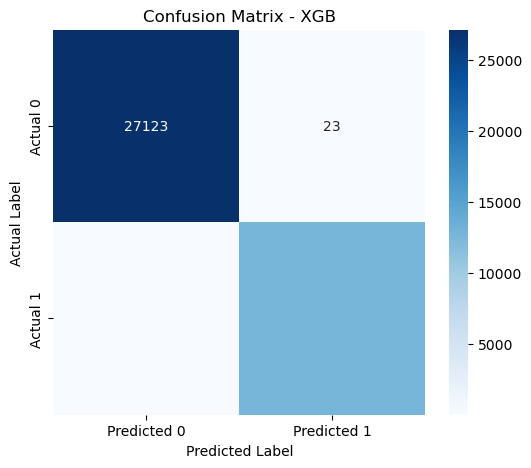

LightGBM
Model: LightGBM
Accuracy score: 0.9990
Precision score: 0.9982
Recall score: 0.9986
F1 score: 0.9984


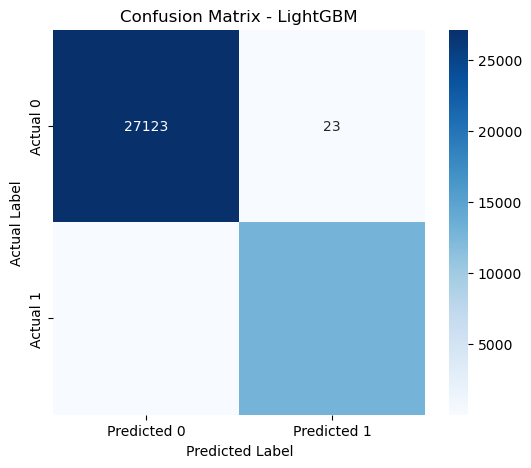

CatBoost
Model: CatBoost
Accuracy score: 0.9990
Precision score: 0.9986
Recall score: 0.9984
F1 score: 0.9985


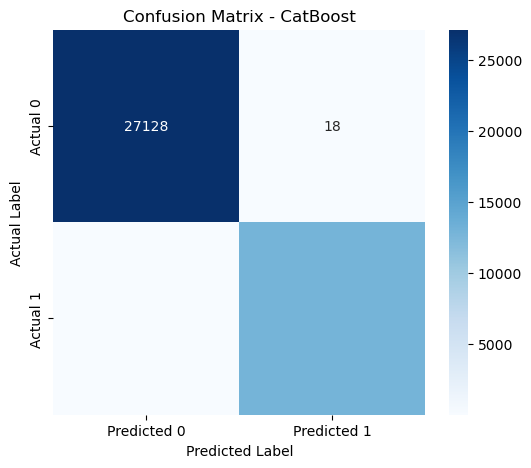

RandomForest
Model: RandomForest
Accuracy score: 1.0000
Precision score: 1.0000
Recall score: 0.9998
F1 score: 0.9999


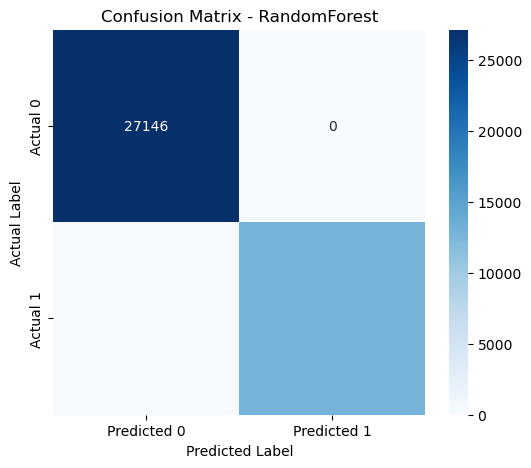

AdaBoost
Model: AdaBoost
Accuracy score: 1.0000
Precision score: 1.0000
Recall score: 0.9998
F1 score: 0.9999


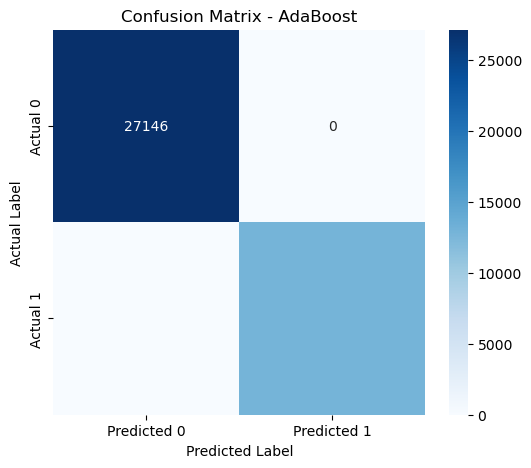

GradientBoosting
Model: GradientBoosting
Accuracy score: 1.0000
Precision score: 1.0000
Recall score: 0.9998
F1 score: 0.9999


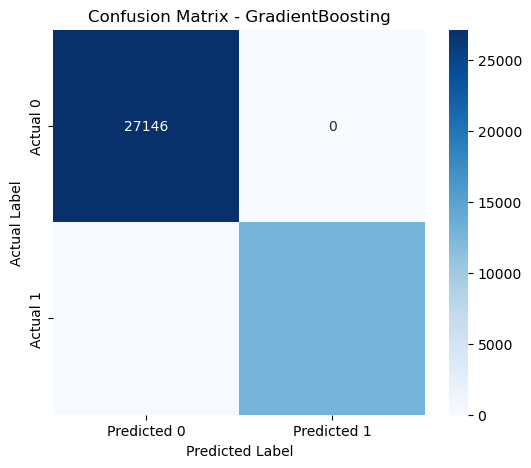

LogisticRegression
Model: LogisticRegression
Accuracy score: 0.9599
Precision score: 0.9107
Recall score: 0.9704
F1 score: 0.9396


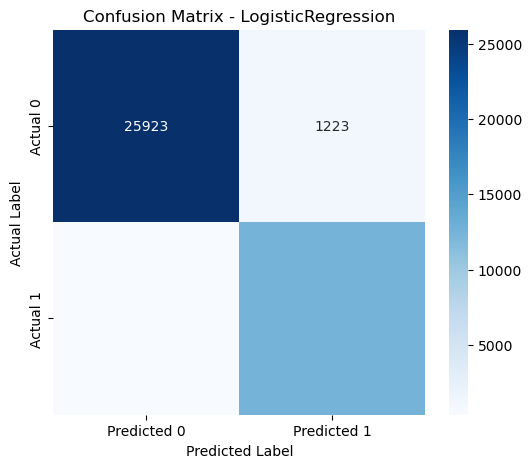

In [14]:
xgb_clf = XGBClassifier(verbosity=0)
lgbm_clf = LGBMClassifier(verbose=-1)
catboost_clf = CatBoostClassifier(verbose=0)
rf_clf = RandomForestClassifier()
adaboost_clf = AdaBoostClassifier()
gradient_clf = GradientBoostingClassifier(verbose=0)
logistic_reg = LogisticRegression()

estimators={
    'XGB':xgb_clf,
    'LightGBM': lgbm_clf,
    'CatBoost': catboost_clf,
    'RandomForest': rf_clf,
    'AdaBoost': adaboost_clf,
    'GradientBoosting': gradient_clf,
    'LogisticRegression': logistic_reg
}
models={}
for name, estimator in estimators.items():
    models[f'{name}']=estimator

for name, model in models.items():
    print(name)
    preds=cross_val_predict(model,X_train, y_train, cv=5)
    model_evaluation(y_train, preds, name)

# Dostrajanie parametrów
Postarajmy się znaleźć optymalne parametry modelu.

In [18]:
# Funkcja do strojenia hiperparametrów modelu za pomocą GridSearchCV

def tune_model(model, param_grid, X_train, y_train, cv=5, scoring='roc_auc', verbose=2):
    
    grid_search = GridSearchCV(
        estimator=model,
        param_grid=param_grid,
        scoring=scoring,
        cv=cv,
        verbose=verbose,
        n_jobs=-1
    )
    
    print(f"🔍 Start GridSearchCV dla {model.__class__.__name__}...")
    grid_search.fit(X_train, y_train)
    
    print(f"\n✅ Najlepsze parametry: {grid_search.best_params_}")
    print(f"🏆 Najlepszy wynik ({scoring}): {grid_search.best_score_:.4f}")
    
    return grid_search

# 1. Random Forest

## Random Search

In [28]:
from sklearn.model_selection import RandomizedSearchCV

rf = RandomForestClassifier(random_state=42, min_samples_split=10, min_samples_leaf=4, max_features=None, bootstrap=True)

param_dist = {
    'n_estimators': np.arange(100, 1000, 100),
    'max_depth': [None] + list(np.arange(5, 50, 5)),
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', None],
    'bootstrap': [True, False]
}

random_search = RandomizedSearchCV(
    rf,
    param_distributions=param_dist,
    n_iter=50,                # liczba losowań kombinacji
    cv=5,                     # 5-krotna kroswalidacja
    scoring='roc_auc',        # lub inna metryka
    verbose=2,
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train, y_train)

print("Najlepsze parametry:", random_search.best_params_)
print("Najlepsze ROC AUC:", random_search.best_score_)

Fitting 5 folds for each of 50 candidates, totalling 250 fits
Najlepsze parametry: {'n_estimators': 900, 'min_samples_split': 10, 'min_samples_leaf': 4, 'max_features': None, 'max_depth': 40, 'bootstrap': True}
Najlepsze ROC AUC: 1.0


## Grid Search

In [19]:
from sklearn.model_selection import GridSearchCV

rf = RandomForestClassifier(random_state=42, min_samples_split=10, min_samples_leaf=4, max_features=None, bootstrap=True)

param_grid_rf = {
    'n_estimators': [850, 900, 950],
    'max_depth': [38, 40, 42]
}

grid_search_rf = tune_model(rf, param_grid_rf, X_train, y_train)

🔍 Start GridSearchCV dla RandomForestClassifier...
Fitting 5 folds for each of 9 candidates, totalling 45 fits

✅ Najlepsze parametry: {'max_depth': 38, 'n_estimators': 850}
🏆 Najlepszy wynik (roc_auc): 1.0000


# 2. XGBoost

In [20]:
xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)

param_grid_xgb = {
    'n_estimators': [100, 300, 500],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

grid_search_xgb = tune_model(xgb, param_grid_xgb, X_train, y_train)

🔍 Start GridSearchCV dla XGBClassifier...
Fitting 5 folds for each of 108 candidates, totalling 540 fits

✅ Najlepsze parametry: {'colsample_bytree': 1.0, 'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100, 'subsample': 1.0}
🏆 Najlepszy wynik (roc_auc): 1.0000


# 3. AdaBoost

In [21]:
from sklearn.ensemble import AdaBoostClassifier

ada = AdaBoostClassifier(random_state=42)

param_grid_ada = {
    'n_estimators': [50, 100, 300],
    'learning_rate': [0.01, 0.1, 1.0]
}

grid_search_ada = tune_model(ada, param_grid_ada, X_train, y_train)

🔍 Start GridSearchCV dla AdaBoostClassifier...
Fitting 5 folds for each of 9 candidates, totalling 45 fits

✅ Najlepsze parametry: {'learning_rate': 0.01, 'n_estimators': 50}
🏆 Najlepszy wynik (roc_auc): 0.9999


# 4. Gradient Boosting

In [22]:
gbc = GradientBoostingClassifier(random_state=42)

param_grid_gbc = {
    'n_estimators': [100, 300, 500],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 5, 7],
    'subsample': [0.8, 1.0]
}

grid_search_gbc = tune_model(gbc, param_grid_gbc, X_train, y_train)

🔍 Start GridSearchCV dla GradientBoostingClassifier...
Fitting 5 folds for each of 54 candidates, totalling 270 fits

✅ Najlepsze parametry: {'learning_rate': 0.2, 'max_depth': 5, 'n_estimators': 100, 'subsample': 1.0}
🏆 Najlepszy wynik (roc_auc): 0.9999


# Finalne Modele

Model: XGBoostClassifier
Accuracy score: 0.9990
Precision score: 0.9987
Recall score: 0.9982
F1 score: 0.9984


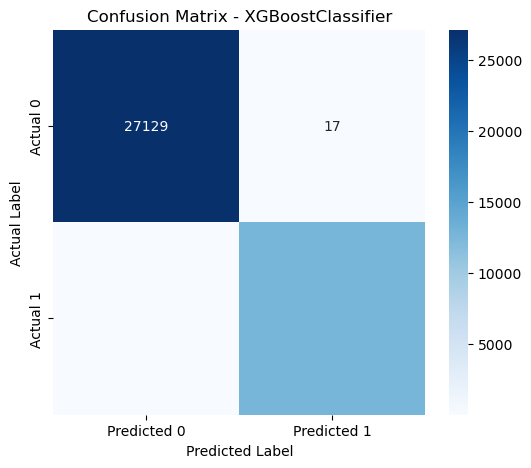

In [25]:
xgb_final_model = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42, colsample_bytree=1.0,
                    learning_rate=0.1, max_depth=3, n_estimators=100, subsample=1.0)
                    
xgb_preds = cross_val_predict(xgb_final_model, X_train, y_train, cv=5)
model_evaluation(y_train, xgb_preds, 'XGBoostClassifier')

Model: RandomForestClassifier
Accuracy score: 1.0000
Precision score: 1.0000
Recall score: 0.9998
F1 score: 0.9999


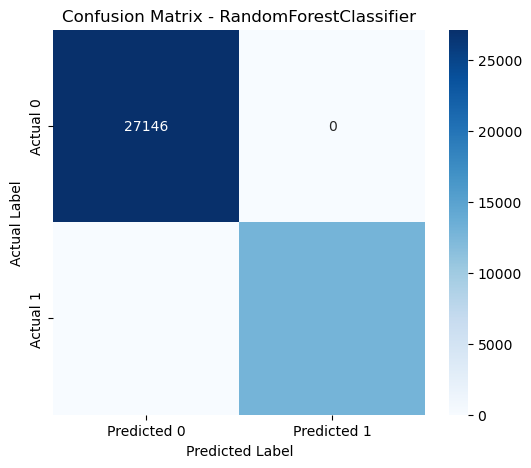

In [26]:
rf_final_model = RandomForestClassifier(random_state=42, n_estimators=850, min_samples_split=10, min_samples_leaf=4, 
                               max_depth=38, max_features=None, bootstrap=True)

rf_preds = cross_val_predict(rf_final_model, X_train, y_train, cv=5)
model_evaluation(y_train, rf_preds, 'RandomForestClassifier')

# Test odporności na szum w danych

In [27]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

def add_noise(X, noise_level=0.01, seed=42):

    np.random.seed(seed)
    X_noisy = X.copy()
    numeric_cols = X_noisy.select_dtypes(include=np.number).columns
    
    for col in numeric_cols:
        noise = np.random.normal(0, noise_level, size=X_noisy.shape[0])
        X_noisy[col] += noise
    
    return X_noisy

def test_model_robustness_plot(model, X_test, y_test, model_name="Model", noise_levels=[0.0, 0.01, 0.05, 0.1]):

    print(f"\n Test odporności dla: {model_name}")

    roc_auc_scores = []
    
    for noise in noise_levels:
        if noise == 0:
            X_mod = X_test.copy()
        else:
            X_mod = add_noise(X_test, noise_level=noise)
        
        y_pred_proba = model.predict_proba(X_mod)[:,1]
        roc_auc = roc_auc_score(y_test, y_pred_proba)
        roc_auc_scores.append(roc_auc)
        
        print(f"Noise Level {noise:.2f} -> ROC AUC: {roc_auc:.4f}")
    
    # Wykres
    plt.figure(figsize=(8, 5))
    plt.plot(noise_levels, roc_auc_scores, marker='o')
    plt.title(f"Robustness Test - {model_name}")
    plt.xlabel("Poziom szumu (noise level)")
    plt.ylabel("ROC AUC")
    plt.grid(True)
    plt.ylim(0.0, 1.05)
    plt.show()



🚀 Test odporności dla: Random Forest
Noise Level 0.00 -> ROC AUC: 1.0000
Noise Level 0.01 -> ROC AUC: 0.9917
Noise Level 0.05 -> ROC AUC: 0.9616
Noise Level 0.10 -> ROC AUC: 0.8909


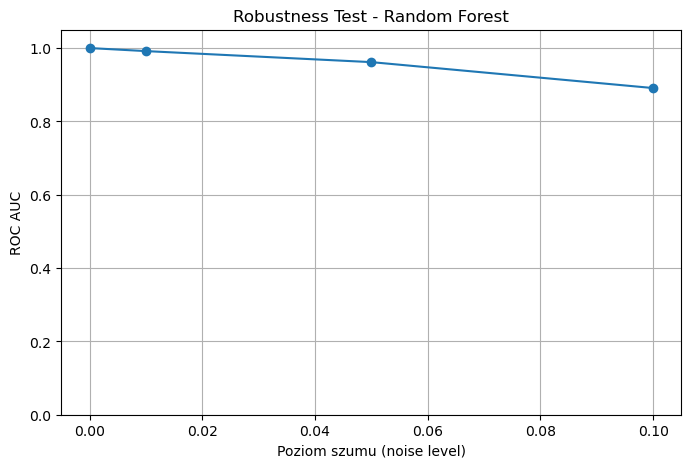


🚀 Test odporności dla: XGBoost
Noise Level 0.00 -> ROC AUC: 1.0000
Noise Level 0.01 -> ROC AUC: 0.9562
Noise Level 0.05 -> ROC AUC: 0.9297
Noise Level 0.10 -> ROC AUC: 0.8859


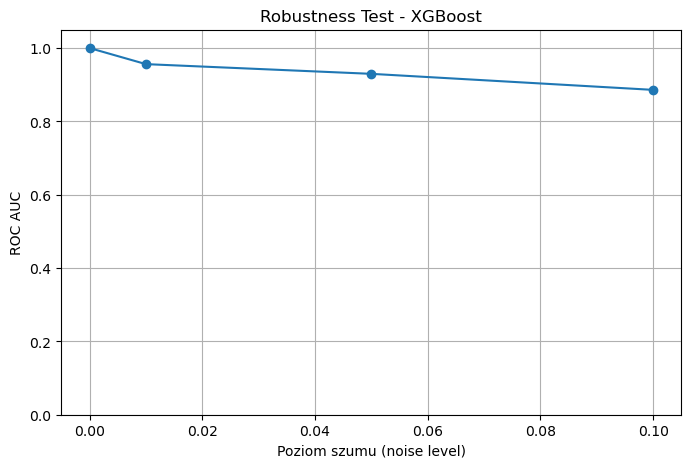

In [31]:
rf_final_model.fit(X_train, y_train)
test_model_robustness_plot(rf_final_model, X_test, y_test, model_name="Random Forest")

xgb_final_model.fit(X_train, y_train)
test_model_robustness_plot(xgb_final_model, X_test, y_test, model_name="XGBoost")

# Wybór
Finalnie wybraliśmy Random Forest.

# Testowanie modelu
Ewaluacja modelu na bazie danych walidacyjnych (ok. 20% zbioru danych, na którym nie był trenowany model).

CPU times: total: 24.5 s
Wall time: 25.2 s
Model: RandomForestClasiffier
Accuracy score: 1.0000
Precision score: 1.0000
Recall score: 1.0000
F1 score: 1.0000


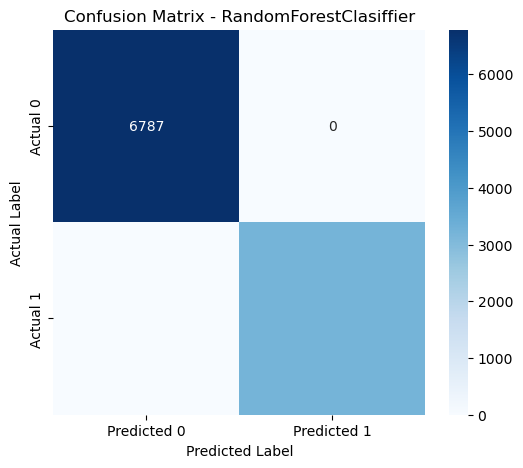

In [16]:
model = RandomForestClassifier(random_state=42, n_estimators=850, min_samples_split=10, min_samples_leaf=4, 
                               max_depth=38, max_features=None, bootstrap=True)
%time model.fit(X_train,y_train)
preds=model.predict(X_test)
model_evaluation(y_test, preds, 'RandomForestClasiffier')

In [32]:
from sklearn.metrics import classification_report

print(classification_report(y_test, preds))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      6787
           1       1.00      1.00      1.00      3213

    accuracy                           1.00     10000
   macro avg       1.00      1.00      1.00     10000
weighted avg       1.00      1.00      1.00     10000



# Wyniki
Model osiągnął bardzo dobre wyniki zmierzone metrykami dobranymi dla naszego problemu. 